# Laboratorio 8 — DuckDB, Parquet y tablero sobre TLC Trip Records

**Objetivo:** construir un flujo reproducible para analizar los viajes de taxis
amarillos y verdes de NYC publicados por la TLC: descarga incremental de Parquet
(2024, 2025 y 2026), consulta directa con DuckDB, análisis exploratorio, tabla
materializada, benchmark Parquet vs tabla, indicadores, tablero en Metabase y
comparación interanual con periodos equivalentes.

Las primeras secciones documentan la preparación y la exploración inicial de 2026;
las siguientes amplían el análisis de forma incremental.

## Configuración y rutas

Se localiza la raíz del proyecto buscando `docker-compose.yml` hacia arriba desde
el directorio de trabajo actual. Así el notebook funciona dentro de Docker
(`/workspace`) y también en ejecución local.


In [1]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import duckdb
import pandas as pd
import pyarrow as pa


def find_project_root(start: Path | None = None) -> Path:
    """Recorre cwd y padres hasta encontrar docker-compose.yml.

    Si no está montado, acepta un directorio con data/, notebooks/ y scripts/.
    """
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "docker-compose.yml").is_file():
            return candidate
        markers = (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
            and (candidate / "scripts" / "download_data.py").is_file()
        )
        if markers:
            return candidate
    raise FileNotFoundError(
        "No se encontró la raíz del proyecto; abre el notebook desde el lab."
    )


PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
SQL_DIR = PROJECT_ROOT / "sql"
DOCS_DIR = PROJECT_ROOT / "docs"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

for path in (DATA_RAW, DATA_PROCESSED, SQL_DIR, DOCS_DIR):
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("DATA_RAW       =", DATA_RAW)
print("DATA_PROCESSED =", DATA_PROCESSED)
print("SQL_DIR        =", SQL_DIR)
print("DOCS_DIR       =", DOCS_DIR)


PROJECT_ROOT   = /workspace
DATA_RAW       = /workspace/data/raw
DATA_PROCESSED = /workspace/data/processed
SQL_DIR        = /workspace/sql
DOCS_DIR       = /workspace/docs


## Ambiente reproducible

Servicios definidos en `docker-compose.yml`:

| Servicio | Función | Puerto local |
|---|---|---|
| `analysis` | JupyterLab + Python/DuckDB para el análisis | http://localhost:8888 |
| `metabase` | BI / tableros (configuración posterior) | http://localhost:3000 |

Dentro del contenedor de análisis se montan en `/workspace`:

- `data/`
- `notebooks/`
- `scripts/`
- `sql/`
- `docs/`

Un ambiente reproducible importa porque fija versiones, evita diferencias entre
máquinas y permite volver a ejecutar el análisis sin depender de paquetes
instalados “a mano” en el host.


In [2]:
print("Python :", sys.version.split()[0])
print("DuckDB :", duckdb.__version__)
print("Pandas :", pd.__version__)
print("PyArrow:", pa.__version__)


Python : 3.11.17
DuckDB : 1.1.3
Pandas : 2.2.3
PyArrow: 18.1.0


## Estructura del proyecto

- `data/raw/`: Parquet originales descargados de la TLC.
- `data/processed/`: base DuckDB materializada u otros artefactos generados.
- `notebooks/`: análisis reproducible y documentación ejecutable.
- `scripts/`: automatización reutilizable (descarga).
- `sql/`: consultas SQL importantes organizadas por propósito.
- `docs/`: resultados pequeños, evidencia del tablero o notas auxiliares.


## Inventario de datos 2026

La descarga se hace con `scripts/download_data.py` (yellow y green, año 2026).
Aquí solo se resume el estado local y se verifica completitud respecto a lo
publicado por la TLC.


In [3]:
import importlib.util
import sys

spec = importlib.util.spec_from_file_location(
    "download_data", SCRIPTS_DIR / "download_data.py"
)
download_data = importlib.util.module_from_spec(spec)
assert spec.loader is not None
# Necesario para que @dataclass resuelva anotaciones al cargar vía importlib
sys.modules[spec.name] = download_data
spec.loader.exec_module(download_data)

YEAR = 2026
TAXI_TYPES = ("yellow", "green")

# Descarga incremental: solo baja meses publicados que falten (no-op si ya existen)
for taxi_type in TAXI_TYPES:
    download_data.descargar(taxi_type, YEAR, PROJECT_ROOT)

# Resumen de verificación (meses publicados vs archivos locales)
verify_summary = download_data.verify_completeness(
    PROJECT_ROOT, TAXI_TYPES, YEAR
)
is_complete = download_data.print_verification(verify_summary)



=== Verificación de completitud ===
Completo = todos los meses publicados por la TLC están locales y con tamaño > 0 (no se exigen 12 meses).
Publicados:              16
Locales válidos:         16
Ausentes:                0
Locales no publicados:   0
  green 2026: 8/8 publicados | meses locales=[1, 2, 3, 4, 5, 6, 7, 8]
  yellow 2026: 8/8 publicados | meses locales=[1, 2, 3, 4, 5, 6, 7, 8]

Resultado: COMPLETO


In [4]:
rows = []
for taxi_type in TAXI_TYPES:
    year_dir = DATA_RAW / taxi_type / str(YEAR)
    if not year_dir.is_dir():
        continue
    for path in sorted(year_dir.glob("*.parquet")):
        match = re.search(r"(\d{4})-(\d{2})", path.name)
        if not match:
            continue
        year = int(match.group(1))
        month = int(match.group(2))
        size_mb = path.stat().st_size / (1024 * 1024)
        rows.append(
            {
                "taxi_type": taxi_type,
                "year": year,
                "month": month,
                "filename": path.name,
                "size_mb": round(size_mb, 2),
            }
        )

inventory_df = pd.DataFrame(rows).sort_values(["taxi_type", "year", "month"])
display(inventory_df)

n_yellow = int((inventory_df["taxi_type"] == "yellow").sum()) if not inventory_df.empty else 0
n_green = int((inventory_df["taxi_type"] == "green").sum()) if not inventory_df.empty else 0
total_mb = float(inventory_df["size_mb"].sum()) if not inventory_df.empty else 0.0

print(f"Archivos yellow: {n_yellow}")
print(f"Archivos green : {n_green}")
print(f"Tamaño total   : {total_mb:.2f} MB")
print(
    "Meses yellow   :",
    sorted(inventory_df.loc[inventory_df.taxi_type == "yellow", "month"].tolist()),
)
print(
    "Meses green    :",
    sorted(inventory_df.loc[inventory_df.taxi_type == "green", "month"].tolist()),
)
print("Verificación   :", "COMPLETO" if is_complete else "INCOMPLETO")


,taxi_type,year,month,filename,size_mb
8,green,2026,1,green_tripdata_2026-01.parquet,0.95
9,green,2026,2,green_tripdata_2026-02.parquet,0.88
10,green,2026,3,green_tripdata_2026-03.parquet,1.03
11,green,2026,4,green_tripdata_2026-04.parquet,1.03
12,green,2026,5,green_tripdata_2026-05.parquet,1.05
13,green,2026,6,green_tripdata_2026-06.parquet,1.03
14,green,2026,7,green_tripdata_2026-07.parquet,0.97
15,green,2026,8,green_tripdata_2026-08.parquet,0.96
0,yellow,2026,1,yellow_tripdata_2026-01.parquet,61.19
1,yellow,2026,2,yellow_tripdata_2026-02.parquet,55.96


Archivos yellow: 8
Archivos green : 8
Tamaño total   : 495.66 MB
Meses yellow   : [1, 2, 3, 4, 5, 6, 7, 8]
Meses green    : [1, 2, 3, 4, 5, 6, 7, 8]
Verificación   : COMPLETO


## Conexión DuckDB

Conexión **en memoria**. Todavía no se materializa una tabla persistente: se
consulta Parquet con `read_parquet` y vistas temporales normalizadas.


In [5]:
con = duckdb.connect()  # in-memory

yellow_glob = str(DATA_RAW / "yellow" / str(YEAR) / "*.parquet")
green_glob = str(DATA_RAW / "green" / str(YEAR) / "*.parquet")

con.execute(f"""
CREATE OR REPLACE TEMP VIEW yellow_trips AS
SELECT
    'yellow' AS taxi_type,
    tpep_pickup_datetime AS pickup_datetime,
    tpep_dropoff_datetime AS dropoff_datetime,
    passenger_count,
    trip_distance,
    PULocationID AS pu_location_id,
    DOLocationID AS do_location_id,
    payment_type,
    fare_amount,
    tip_amount,
    tolls_amount,
    total_amount,
    filename AS source_file,
    CAST(regexp_extract(filename, '(\d{{4}})-(\d{{2}})', 1) AS INTEGER) AS source_year,
    CAST(regexp_extract(filename, '(\d{{4}})-(\d{{2}})', 2) AS INTEGER) AS source_month
FROM read_parquet('{yellow_glob}', filename = true, union_by_name = true);
""")

con.execute(f"""
CREATE OR REPLACE TEMP VIEW green_trips AS
SELECT
    'green' AS taxi_type,
    lpep_pickup_datetime AS pickup_datetime,
    lpep_dropoff_datetime AS dropoff_datetime,
    passenger_count,
    trip_distance,
    PULocationID AS pu_location_id,
    DOLocationID AS do_location_id,
    payment_type,
    fare_amount,
    tip_amount,
    tolls_amount,
    total_amount,
    filename AS source_file,
    CAST(regexp_extract(filename, '(\d{{4}})-(\d{{2}})', 1) AS INTEGER) AS source_year,
    CAST(regexp_extract(filename, '(\d{{4}})-(\d{{2}})', 2) AS INTEGER) AS source_month
FROM read_parquet('{green_glob}', filename = true, union_by_name = true);
""")

con.execute("""
CREATE OR REPLACE TEMP VIEW trips AS
SELECT * FROM yellow_trips
UNION ALL BY NAME
SELECT * FROM green_trips;
""")

print("Vistas creadas: yellow_trips, green_trips, trips")
print(con.execute("SELECT taxi_type, COUNT(*) AS n FROM trips GROUP BY 1 ORDER BY 1").fetchdf())


Vistas creadas: yellow_trips, green_trips, trips
  taxi_type         n
0     green    337114
1    yellow  29703355


## Exploración directa de archivos Parquet

### ¿Qué significa consultar directamente un archivo Parquet?

DuckDB puede ejecutar SQL sobre archivos Parquet con `read_parquet` **sin**
importarlos antes a una tabla persistente. El motor lee (de forma columnar) solo
lo necesario para responder la consulta.

### ¿Por qué puede ser útil con grandes volúmenes?

- lectura columnar: no hay que cargar todas las columnas;
- predicate pushdown cuando aplica (filtros cerca del almacenamiento);
- se evita una etapa obligatoria de carga/ETL previa;
- menor duplicación de datos en disco;
- es fácil agregar nuevos archivos al glob sin reescribir una base.


### Inventario de archivos (desde el sistema de archivos)

Ya se generó la tabla de inventario arriba. A continuación, conteos de registros
directamente sobre Parquet.


### Conteo de registros

**Objetivo:** cuantificar el volumen total y por tipo/mes.

**Fuente:** Parquet yellow/green 2026 vía vista `trips`.

**Consulta:** se muestra en la siguiente celda.

**Resultado:** se genera al ejecutar.

**Interpretación/decisión:** confirmar que hay datos suficientes de ambos tipos
antes de análisis posteriores.


In [6]:
counts_by_type = con.execute("""
SELECT taxi_type, COUNT(*) AS n_rows
FROM trips
GROUP BY taxi_type
ORDER BY taxi_type;
""").fetchdf()

counts_by_month = con.execute("""
SELECT taxi_type, source_year, source_month, COUNT(*) AS n_rows
FROM trips
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3;
""").fetchdf()

total_rows = int(counts_by_type["n_rows"].sum())
print(f"Registros totales: {total_rows:,}")
display(counts_by_type)
display(counts_by_month)


Registros totales: 30,040,469


,taxi_type,n_rows
0,green,337114
1,yellow,29703355


,taxi_type,source_year,source_month,n_rows
0,green,2026,1,40272
1,green,2026,2,37373
2,green,2026,3,44208
3,green,2026,4,44238
4,green,2026,5,44921
5,green,2026,6,44163
6,green,2026,7,41252
7,green,2026,8,40687
8,yellow,2026,1,3724889
9,yellow,2026,2,3399866


### Columnas y tipos

**Objetivo:** documentar el esquema de yellow, green y de la vista normalizada,
y señalar diferencias entre tipos.

**Fuente:** archivos Parquet originales + vista `trips`.

**Consulta:** `DESCRIBE` sobre `read_parquet` y sobre `trips`.

**Resultado:** tablas de esquema al ejecutar.

**Interpretación/decisión:** la vista normalizada unifica nombres (`tpep_*` /
`lpep_*` → `pickup_datetime` / `dropoff_datetime`) sin reescribir los archivos.


In [7]:
schema_yellow = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{yellow_glob}', filename = true, union_by_name = true);
""").fetchdf()

schema_green = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{green_glob}', filename = true, union_by_name = true);
""").fetchdf()

schema_trips = con.execute("DESCRIBE trips;").fetchdf()

print("Esquema yellow")
display(schema_yellow)
print("Esquema green")
display(schema_green)
print("Esquema vista normalizada (trips)")
display(schema_trips)

yellow_cols = set(schema_yellow["column_name"])
green_cols = set(schema_green["column_name"])
only_yellow = sorted(yellow_cols - green_cols)
only_green = sorted(green_cols - yellow_cols)
print("Solo en yellow:", only_yellow)
print("Solo en green :", only_green)


Esquema yellow


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


Esquema green


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,lpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,lpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,store_and_fwd_flag,VARCHAR,YES,None,None,None
4,RatecodeID,BIGINT,YES,None,None,None
5,PULocationID,INTEGER,YES,None,None,None
6,DOLocationID,INTEGER,YES,None,None,None
7,passenger_count,BIGINT,YES,None,None,None
8,trip_distance,DOUBLE,YES,None,None,None
9,fare_amount,DOUBLE,YES,None,None,None


Esquema vista normalizada (trips)


,column_name,column_type,null,key,default,extra
0,taxi_type,VARCHAR,YES,None,None,None
1,pickup_datetime,TIMESTAMP,YES,None,None,None
2,dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,pu_location_id,INTEGER,YES,None,None,None
6,do_location_id,INTEGER,YES,None,None,None
7,payment_type,BIGINT,YES,None,None,None
8,fare_amount,DOUBLE,YES,None,None,None
9,tip_amount,DOUBLE,YES,None,None,None


Solo en yellow: ['Airport_fee', 'tpep_dropoff_datetime', 'tpep_pickup_datetime']
Solo en green : ['ehail_fee', 'lpep_dropoff_datetime', 'lpep_pickup_datetime', 'trip_type']


### Muestra de registros

**Objetivo:** inspeccionar unas pocas filas de cada tipo.

**Fuente:** vista `trips`.

**Consulta:** `LIMIT 5` por tipo.

**Resultado:** muestra pequeña al ejecutar.

**Interpretación/decisión:** verificar que la normalización de columnas y
`source_file` / mes se vean coherentes.


In [8]:
sample_df = con.execute("""
(
    SELECT * FROM trips WHERE taxi_type = 'yellow' LIMIT 5
)
UNION ALL BY NAME
(
    SELECT * FROM trips WHERE taxi_type = 'green' LIMIT 5
);
""").fetchdf()
display(sample_df)


,taxi_type,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pu_location_id,do_location_id,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,source_file,source_year,source_month
0,yellow,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,239,238,1,7.2,3.66,0.0,15.86,/workspace/data/raw/yellow/2026/yellow_tripdat...,2026,1
1,yellow,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,163,162,2,7.9,0.00,0.0,13.65,/workspace/data/raw/yellow/2026/yellow_tripdat...,2026,1
2,yellow,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,43,237,1,10.7,2.50,0.0,18.95,/workspace/data/raw/yellow/2026/yellow_tripdat...,2026,1
3,yellow,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,142,209,1,38.7,11.11,0.0,55.56,/workspace/data/raw/yellow/2026/yellow_tripdat...,2026,1
4,yellow,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,88,144,1,13.5,3.85,0.0,23.10,/workspace/data/raw/yellow/2026/yellow_tripdat...,2026,1
5,green,2026-01-01 00:27:58,2026-01-01 00:55:16,2,6.20,65,233,1,31.7,7.50,0.0,45.20,/workspace/data/raw/green/2026/green_tripdata_...,2026,1
6,green,2026-01-01 00:44:33,2026-01-01 01:32:56,5,5.36,66,188,1,50.0,10.20,0.0,61.20,/workspace/data/raw/green/2026/green_tripdata_...,2026,1
7,green,2026-01-01 00:23:45,2026-01-01 00:45:03,4,10.60,65,179,1,41.5,2.00,0.0,46.00,/workspace/data/raw/green/2026/green_tripdata_...,2026,1
8,green,2026-01-01 00:44:33,2026-01-01 01:00:45,1,4.20,42,141,2,19.8,0.00,0.0,25.05,/workspace/data/raw/green/2026/green_tripdata_...,2026,1
9,green,2026-01-01 00:46:04,2026-01-01 01:04:40,1,2.76,95,82,2,19.1,0.00,0.0,21.60,/workspace/data/raw/green/2026/green_tripdata_...,2026,1


## Calidad de datos inicial

No se eliminan registros todavía: el objetivo es **cuantificar** problemas.

Umbral de velocidad sospechosa: **100 mph**. Es una regla analítica de
detección (viajes con duración positiva y distancia no negativa). No implica
por sí sola que el registro sea definitivamente inválido.


### Datetimes nulos y orden temporal

**Objetivo:** medir nulos en pickup/dropoff y casos con dropoff ≤ pickup.

**Fuente:** vista `trips`.

**Consulta:** agregaciones con `FILTER`.

**Resultado:** al ejecutar.

**Interpretación/decisión:** estos casos suelen excluirse en análisis de
duración/velocidad.


In [9]:
datetime_quality = con.execute("""
SELECT
    taxi_type,
    COUNT(*) AS n_rows,
    COUNT(*) FILTER (WHERE pickup_datetime IS NULL) AS null_pickup,
    COUNT(*) FILTER (WHERE dropoff_datetime IS NULL) AS null_dropoff,
    COUNT(*) FILTER (
        WHERE pickup_datetime IS NOT NULL
          AND dropoff_datetime IS NOT NULL
          AND dropoff_datetime <= pickup_datetime
    ) AS dropoff_le_pickup
FROM trips
GROUP BY taxi_type
ORDER BY taxi_type;
""").fetchdf()
display(datetime_quality)


,taxi_type,n_rows,null_pickup,null_dropoff,dropoff_le_pickup
0,green,337114,0,0,234
1,yellow,29703355,0,0,371683


### Distancia, tarifas y pasajeros

**Objetivo:** detectar distancias negativas/cero, montos negativos y pasajeros
negativos.

**Fuente:** vista `trips`.

**Consulta:** conteos con filtros.

**Resultado:** al ejecutar.

**Interpretación/decisión:** cero distancia puede ser válido en algunos casos
(errores de GPS o viajes cancelados); negativos suelen ser anomalías.


In [10]:
amount_quality = con.execute("""
SELECT
    taxi_type,
    COUNT(*) FILTER (WHERE trip_distance < 0) AS negative_distance,
    COUNT(*) FILTER (WHERE trip_distance = 0) AS zero_distance,
    COUNT(*) FILTER (WHERE fare_amount < 0) AS negative_fare,
    COUNT(*) FILTER (WHERE total_amount < 0) AS negative_total,
    COUNT(*) FILTER (WHERE passenger_count < 0) AS negative_passengers,
    COUNT(*) FILTER (WHERE passenger_count IS NULL) AS null_passengers,
    COUNT(*) FILTER (WHERE trip_distance IS NULL) AS null_distance,
    COUNT(*) FILTER (WHERE pu_location_id IS NULL) AS null_pu,
    COUNT(*) FILTER (WHERE do_location_id IS NULL) AS null_do,
    COUNT(*) FILTER (WHERE fare_amount IS NULL) AS null_fare,
    COUNT(*) FILTER (WHERE total_amount IS NULL) AS null_total
FROM trips
GROUP BY taxi_type
ORDER BY taxi_type;
""").fetchdf()
display(amount_quality)


,taxi_type,negative_distance,zero_distance,negative_fare,negative_total,negative_passengers,null_passengers,null_distance,null_pu,null_do,null_fare,null_total
0,green,0,12212,999,1023,0,48775,0,0,0,0,0
1,yellow,0,952231,157364,161835,0,7716688,0,0,0,0,0


### Duración excesiva y velocidad implícita

**Objetivo:** contar viajes con duración > 24 h y velocidad implícita > 100 mph
(solo con duración positiva y distancia ≥ 0).

**Fuente:** vista `trips`.

**Consulta:** derivadas de `epoch(dropoff) - epoch(pickup)`.

**Resultado:** al ejecutar.

**Interpretación/decisión:** el umbral de 100 mph es una regla de detección,
no una prueba definitiva de invalidez.


In [11]:
SPEED_THRESHOLD_MPH = 100

duration_speed = con.execute(f"""
SELECT
    taxi_type,
    COUNT(*) FILTER (
        WHERE pickup_datetime IS NOT NULL
          AND dropoff_datetime IS NOT NULL
          AND epoch(dropoff_datetime) - epoch(pickup_datetime) > 24 * 3600
    ) AS duration_over_24h,
    COUNT(*) FILTER (
        WHERE pickup_datetime IS NOT NULL
          AND dropoff_datetime IS NOT NULL
          AND epoch(dropoff_datetime) - epoch(pickup_datetime) > 0
          AND trip_distance >= 0
          AND trip_distance
              / ((epoch(dropoff_datetime) - epoch(pickup_datetime)) / 3600.0)
              > {SPEED_THRESHOLD_MPH}
    ) AS speed_over_{SPEED_THRESHOLD_MPH}_mph
FROM trips
GROUP BY taxi_type
ORDER BY taxi_type;
""").fetchdf()
display(duration_speed)
print(f"Umbral de velocidad usado: {SPEED_THRESHOLD_MPH} mph")


,taxi_type,duration_over_24h,speed_over_100_mph
0,green,4,1023
1,yellow,263,6501


Umbral de velocidad usado: 100 mph


### Percentiles extremos

**Objetivo:** ubicar colas de distancia, tarifa y monto total.

**Fuente:** vista `trips`.

**Consulta:** `approx_quantile`.

**Resultado:** al ejecutar.

**Interpretación/decisión:** percentiles altos ayudan a definir cortes futuros
sin basarse solo en máximos absolutos.


In [12]:
percentiles = con.execute("""
SELECT
    taxi_type,
    approx_quantile(trip_distance, 0.01) AS dist_p01,
    approx_quantile(trip_distance, 0.50) AS dist_p50,
    approx_quantile(trip_distance, 0.99) AS dist_p99,
    approx_quantile(fare_amount, 0.01) AS fare_p01,
    approx_quantile(fare_amount, 0.50) AS fare_p50,
    approx_quantile(fare_amount, 0.99) AS fare_p99,
    approx_quantile(total_amount, 0.01) AS total_p01,
    approx_quantile(total_amount, 0.50) AS total_p50,
    approx_quantile(total_amount, 0.99) AS total_p99
FROM trips
GROUP BY taxi_type
ORDER BY taxi_type;
""").fetchdf()
display(percentiles.round(2))


,taxi_type,dist_p01,dist_p50,dist_p99,fare_p01,fare_p50,fare_p99,total_p01,total_p50,total_p99
0,green,0.0,2.07,17.81,0.00,13.21,80.78,4.94,20.46,97.69
1,yellow,0.0,1.86,19.52,3.18,15.79,81.50,7.80,23.60,106.02


## Conclusiones de la exploración

Cifras obtenidas de la ejecución real sobre Parquet 2026 (ene–ago):

1. **Ambiente:** Docker Compose levanta `analysis` (JupyterLab + DuckDB) en
   `:8888` y `metabase` en `:3000`. Versiones detectadas: Python 3.11.17,
   DuckDB 1.1.3, Pandas 2.2.3, PyArrow 18.1.0.
2. **Descarga:** 16 archivos publicados (8 yellow + 8 green), ~495.66 MB.
   Meses sep–dic aún no publicados. Verificación: **COMPLETO** respecto a lo
   disponible en la TLC. Re-ejecutar el script omite los archivos válidos.
3. **Volumen:** 30,040,469 registros (yellow 29,703,355; green 337,114),
   consultados en memoria con vistas normalizadas, sin base persistente.
4. **Esquema:** yellow aporta `tpep_*` y `Airport_fee`; green aporta `lpep_*`,
   `ehail_fee` y `trip_type`. La vista `trips` unifica datetimes y montos.
5. **Calidad (sin borrar aún):**
   - datetimes nulos: 0 en ambos tipos;
   - dropoff ≤ pickup: ~371.7k yellow, 234 green;
   - distancia 0: ~952k yellow, ~12.2k green (sin distancias negativas);
   - tarifa/total negativos: del orden de 157k–162k en yellow y ~1k en green;
   - `passenger_count` nulo: ~7.7M yellow, ~49k green;
   - duración > 24 h: 263 yellow, 4 green;
   - velocidad implícita > 100 mph (regla analítica): 6,501 yellow, 1,023 green.
6. Medianas razonables (p50 distancia ~1.9–2.1 mi; p50 total ~20–24 USD), con
   colas largas en p99.

Consultas principales también en `sql/exploration.sql`.


## Análisis exploratorio

Esta sección continúa sobre los Parquet de **2026 (enero–agosto, últimos meses publicados por la TLC
al momento de la ejecución)**. Todos los resultados salen de consultas SQL agregadas en DuckDB; Pandas
solo recibe tablas pequeñas para mostrar y graficar.

Para no mezclar planos de análisis se distingue:

- **Datos observados:** lo que viene en los Parquet (columnas originales normalizadas en la vista `trips`).
- **Reglas de calidad:** banderas booleanas que marcan registros problemáticos, sin borrarlos (`trips_enriched`).
- **Decisiones analíticas:** la vista `trips_valid` excluye ciertas banderas para métricas de distancia,
  duración, montos y propinas. Volumen, pagos y calidad se calculan sobre todos los registros.

### 10. Preguntas del análisis exploratorio

1. ¿Cómo varía el número de viajes por mes y por tipo de taxi?
2. ¿Cómo cambia la demanda según la hora del día?
3. ¿Cómo cambia la demanda según el día de la semana?
4. ¿Qué diferencias existen en distancia de viaje entre yellow y green?
5. ¿Qué diferencias existen en duración entre yellow y green?
6. ¿Cómo se distribuyen `fare_amount` y `total_amount`?
7. ¿Qué relación existe entre distancia y tarifa?
8. ¿Cómo se distribuyen los métodos de pago?
9. ¿Cómo se comportan las propinas cuando el dato es aplicable?
10. ¿Qué valores atípicos o inconsistencias aparecen en distancia, duración, tarifa, monto total o velocidad implícita?
11. ¿Cuáles son los `PULocationID` con más viajes?
12. ¿Cuáles son los `DOLocationID` con más viajes?
13. (adicional) ¿Cuántos registros tienen un pickup fuera del mes del archivo que los contiene?

El proyecto no incluye el catálogo de zonas de la TLC, por lo que las ubicaciones se reportan solo como IDs.

### Variables derivadas y reglas

Las variables se calculan una sola vez en la vista `trips_enriched` (definida en `scripts/lab8_common.py`
y copiada en `sql/eda.sql`), de modo que todas las consultas usan la misma definición.

| Variable | Definición |
|---|---|
| `trip_minutes` | `date_diff('second', pickup, dropoff) / 60` |
| `pickup_hour`, `pickup_date`, `pickup_weekday` | hora, fecha y día ISO (1 = lunes … 7 = domingo) del pickup |
| `tip_percentage` | `100 * tip_amount / fare_amount`, solo si `payment_type = 1` (tarjeta) y `fare_amount > 0`; la TLC no registra propinas en efectivo |
| `avg_speed_mph` | `trip_distance / (trip_minutes / 60)`, solo si duración > 0 y distancia ≥ 0 |
| `is_invalid_datetime` | pickup o dropoff nulo, o dropoff ≤ pickup |
| `is_negative_distance` / `is_zero_distance` | distancia < 0 / = 0 |
| `is_negative_fare` / `is_negative_total` | `fare_amount` < 0 / `total_amount` < 0 |
| `is_extreme_speed` | velocidad implícita > 100 mph (regla de dominio) |
| `is_extreme_duration` | duración > 24 h (regla de dominio) |
| `is_pickup_outside_source_month` | el pickup no cae en el año/mes del archivo fuente |

**Regla de `trips_valid`:** excluye `is_invalid_datetime`, `is_negative_distance`, `is_negative_fare`,
`is_negative_total`, `is_extreme_speed` e `is_extreme_duration`. La distancia cero **no** se excluye
(se marca y se reporta) y ningún registro se elimina por estar sobre un percentil: los percentiles
altos solo se usan para documentar colas y, en algunas gráficas, agrupar el último intervalo por legibilidad.

In [13]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import benchmark as bench
import eda_plots as ep
import generate_sql as gsql
import lab8_common as lc
import materialize as mat
import validate_years as vy

pd.set_option("display.max_columns", 40, "display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.labelsize": 10})

YEARS_EDA = [2026]
con_eda = lc.conectar(YEARS_EDA)          # vistas trips -> trips_enriched -> trips_valid sobre Parquet 2026
display(con_eda.execute("DESCRIBE trips_enriched").fetchdf()[["column_name", "column_type"]].T)

t0 = time.perf_counter()
res = lc.correr_eda(con_eda, YEARS_EDA)
print(f"{len(res)} consultas del EDA sobre Parquet {YEARS_EDA} en {time.perf_counter() - t0:.1f} s")


def mostrar(nombre, years=YEARS_EDA, ver_sql=True, redondeo=2):
    """Imprime el SQL (mismo texto que sql/eda.sql) y muestra el resultado ya calculado."""
    if ver_sql:
        print(lc.EDA_QUERIES[nombre].format(years=lc.sql_years(years)))
    display(res[nombre].round(redondeo))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
column_name,taxi_type,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pu_location_id,do_location_id,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,source_file,source_year,source_month,trip_minutes,pickup_hour,pickup_date,pickup_weekday,tip_percentage,avg_speed_mph,is_invalid_datetime,is_negative_distance,is_zero_distance,is_negative_fare,is_negative_total,is_extreme_speed,is_extreme_duration,is_pickup_outside_source_month
column_type,VARCHAR,TIMESTAMP,TIMESTAMP,INTEGER,DOUBLE,INTEGER,INTEGER,INTEGER,DOUBLE,DOUBLE,DOUBLE,DOUBLE,VARCHAR,INTEGER,INTEGER,DOUBLE,BIGINT,DATE,BIGINT,DOUBLE,DOUBLE,BOOLEAN,BOOLEAN,BOOLEAN,BOOLEAN,BOOLEAN,BOOLEAN,BOOLEAN,BOOLEAN


21 consultas del EDA sobre Parquet [2026] en 69.9 s


Primero se cuantifica cuántos registros conserva `trips_valid` y cuántos marca cada bandera
(una fila puede tener varias banderas).

In [14]:
mostrar("volumen_valido")
mostrar("flags_calidad", ver_sql=False)
fl = res["flags_calidad"].set_index("taxi_type")
display((100 * fl[lc.FLAGS + ["n_valid"]].div(fl.n_rows, axis=0)).round(3).add_suffix(" (%)"))

SELECT taxi_type, COUNT(*) AS n_rows, COUNT(*) FILTER (WHERE NOT (is_invalid_datetime OR is_negative_distance OR is_negative_fare OR is_negative_total OR is_extreme_speed OR is_extreme_duration)) AS n_valid
FROM trips_enriched WHERE source_year IN (2026) GROUP BY taxi_type ORDER BY taxi_type


,taxi_type,n_rows,n_valid
0,green,337114,334831
1,yellow,29703355,29162994


,taxi_type,n_rows,is_invalid_datetime,is_negative_distance,is_zero_distance,is_negative_fare,is_negative_total,is_extreme_speed,is_extreme_duration,is_pickup_outside_source_month,n_valid
0,green,337114,234,0,12212,999,1023,1023,4,98,334831
1,yellow,29703355,371683,0,952231,157364,161835,6502,263,146,29162994


,is_invalid_datetime (%),is_negative_distance (%),is_zero_distance (%),is_negative_fare (%),is_negative_total (%),is_extreme_speed (%),is_extreme_duration (%),is_pickup_outside_source_month (%),n_valid (%)
taxi_type,,,,,,,,,
green,0.069,0.0,3.623,0.296,0.303,0.303,0.001,0.029,99.323
yellow,1.251,0.0,3.206,0.530,0.545,0.022,0.001,0.000,98.181


**Interpretación:** `trips_valid` conserva 29,162,994 de 29,703,355 registros yellow (98.2 %) y 334,831 de 337,114 green (99.3 %). En yellow pesan sobre todo el datetime inválido (371,683 casos, 1.25 %) y la tarifa/total negativos (~0.5 %); en green, la tarifa negativa y la velocidad extrema (~0.3 % cada una). La distancia cero es frecuente (3.2 % yellow, 3.6 % green), pero no se excluye. Solo 146 registros yellow y 98 green tienen el pickup fuera del mes de su archivo (pregunta 13).

### 11. Análisis temporal

**Pregunta 1.** ¿Cómo varía el número de viajes por mes y por tipo de taxi? Se cuenta sobre todos los
registros (`trips_enriched`), agrupando por el mes del archivo fuente.

SELECT source_year, source_month, taxi_type, COUNT(*) AS n_trips
FROM trips_enriched WHERE source_year IN (2026) GROUP BY ALL ORDER BY ALL


,source_year,source_month,taxi_type,n_trips
0,2026,1,green,40272
1,2026,1,yellow,3724889
2,2026,2,green,37373
3,2026,2,yellow,3399866
4,2026,3,green,44208
5,2026,3,yellow,3952451
6,2026,4,green,44238
7,2026,4,yellow,3831240
8,2026,5,green,44921
9,2026,5,yellow,4090836


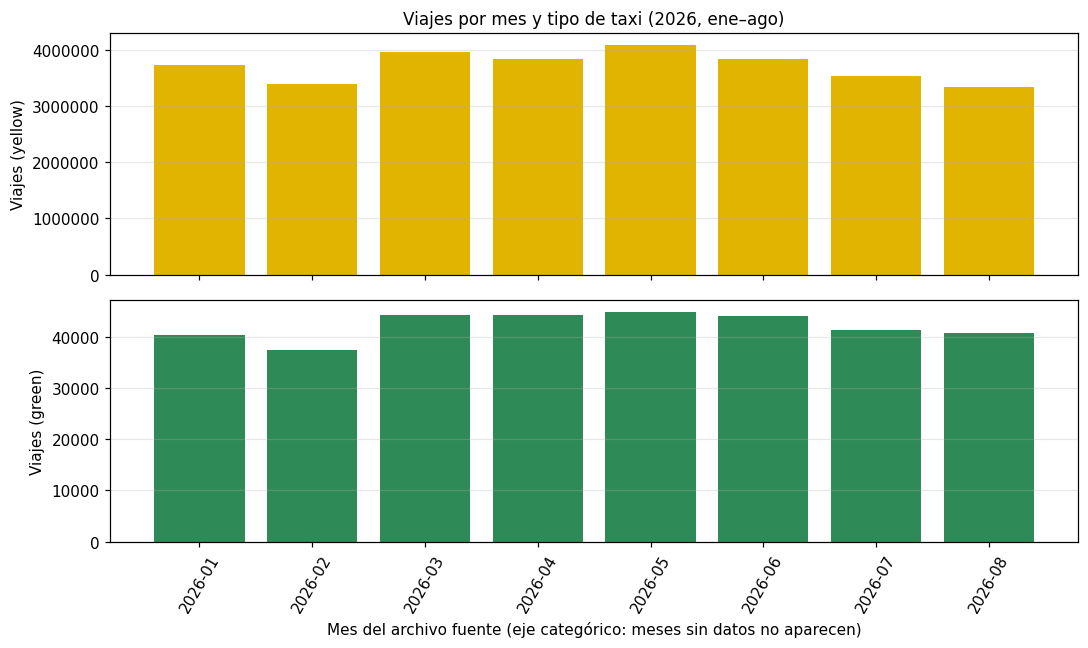

In [15]:
mostrar("volumen_mensual")
ep.plot_volumen_mensual(res["volumen_mensual"], "Viajes por mes y tipo de taxi (2026, ene–ago)")
plt.show()

**Interpretación:** yellow va de 3.34 millones de viajes (agosto) a 4.09 millones (mayo) y green, de 37,373 (febrero) a 44,921 (mayo): ambos tipos tienen su máximo en primavera y bajan en verano. Yellow tiene unas 90 veces más registros que green. Como 2026 solo llega a agosto, no se puede hablar todavía de estacionalidad anual completa.

**Pregunta 2.** ¿Cómo cambia la demanda según la hora del día? Se usa el % de viajes de cada tipo para
comparar perfiles con volúmenes muy distintos. Se excluyen pickups fuera del mes del archivo.

SELECT taxi_type, pickup_hour, COUNT(*) AS n_trips,
       100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY taxi_type) AS pct_trips
FROM trips_enriched WHERE source_year IN (2026) AND pickup_datetime IS NOT NULL AND NOT is_pickup_outside_source_month
GROUP BY taxi_type, pickup_hour ORDER BY taxi_type, pickup_hour


,taxi_type,pickup_hour,n_trips,pct_trips
0,green,0,5287,1.569
1,green,1,3370,1.000
2,green,2,2459,0.730
3,green,3,2041,0.606
4,green,4,2057,0.610
5,green,5,2655,0.788
6,green,6,6811,2.021
7,green,7,14213,4.217
8,green,8,17911,5.315
9,green,9,18819,5.584


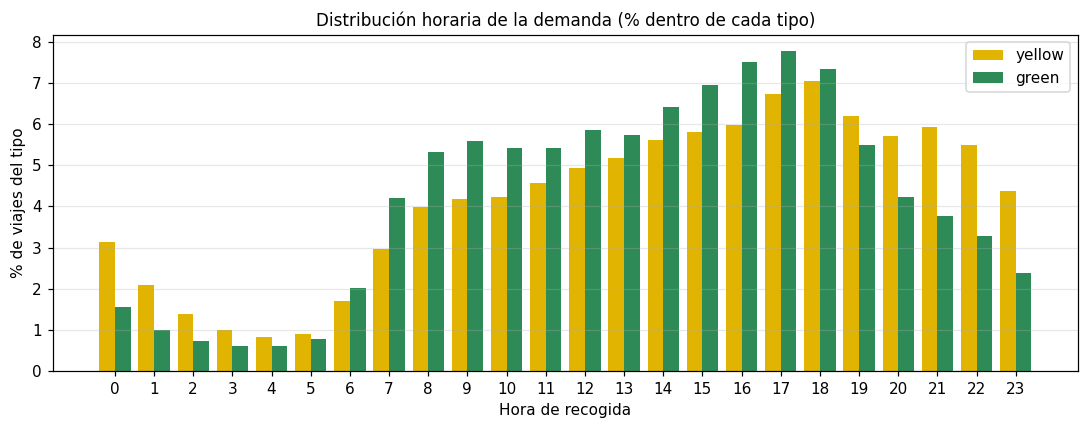

In [16]:
mostrar("demanda_hora", redondeo=3)
ep.plot_demanda_hora(res["demanda_hora"])
plt.show()

**Interpretación:** los dos tipos tienen el pico a las 18 h (7.04 % de los viajes yellow y 7.33 % de los green) y el mínimo de madrugada. Green tiene un perfil algo más marcado en la mañana laboral, mientras que yellow mantiene más actividad por la noche (descripción del patrón, no de sus causas).

**Pregunta 3.** ¿Cómo cambia la demanda según el día de la semana? Como cada día de la semana aparece un
número distinto de veces en el periodo, se compara el promedio de viajes **por día calendario**.

SELECT taxi_type, pickup_weekday, COUNT(*) AS n_trips, COUNT(DISTINCT pickup_date) AS n_days,
       COUNT(*) / COUNT(DISTINCT pickup_date) AS avg_trips_per_day
FROM trips_enriched WHERE source_year IN (2026) AND pickup_datetime IS NOT NULL AND NOT is_pickup_outside_source_month GROUP BY ALL ORDER BY ALL


,taxi_type,pickup_weekday,n_trips,n_days,avg_trips_per_day
0,green,1,47912,35,1368.91
1,green,2,50794,34,1493.94
2,green,3,52679,34,1549.38
3,green,4,55659,35,1590.26
4,green,5,50671,35,1447.74
5,green,6,40764,35,1164.69
6,green,7,38537,35,1101.06
7,yellow,1,3552482,35,101499.49
8,yellow,2,4066804,34,119611.88
9,yellow,3,4339210,34,127623.82


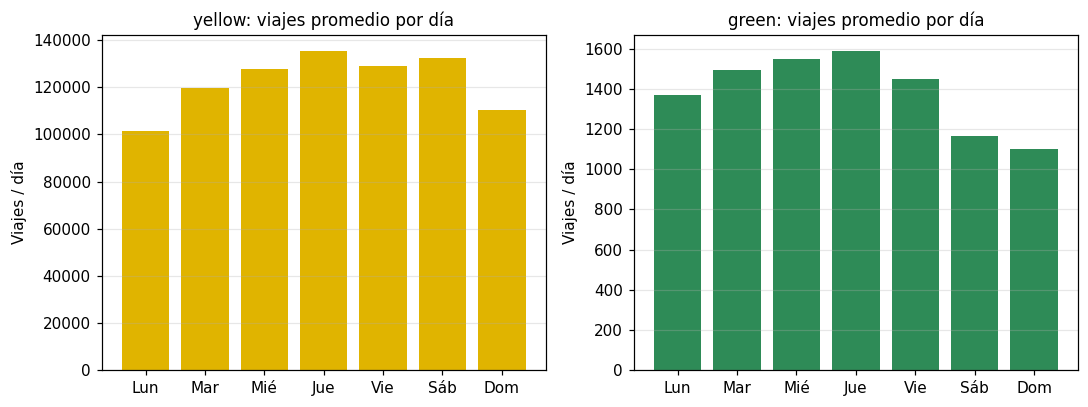

In [17]:
mostrar("demanda_dia_semana")
ep.plot_demanda_dia(res["demanda_dia_semana"])
plt.show()

**Interpretación:** en promedio por día calendario, yellow alcanza su máximo el jueves (135,471 viajes/día) y mantiene un sábado alto (132,375), con el mínimo el lunes (101,499). Green se concentra entre semana (máximo jueves, 1,590/día) y cae en fin de semana (1,101 el domingo). Los patrones semanales son distintos: green tiene un uso más laboral.

### 12. Características de los viajes

**Preguntas 4 y 5.** Distancia (millas) y duración (minutos) de viajes válidos. Se resumen con percentiles
calculados en DuckDB; el boxplot se construye con esos percentiles (caja p25–p75, bigotes p1–p99), sin
traer filas individuales a Pandas.

SELECT taxi_type, 'trip_distance' AS metric, COUNT(trip_distance) AS n, AVG(trip_distance) AS mean, STDDEV_SAMP(trip_distance) AS std,
       MIN(trip_distance) AS min, approx_quantile(trip_distance, 0.01) AS p01, approx_quantile(trip_distance, 0.05) AS p05, approx_quantile(trip_distance, 0.25) AS p25, approx_quantile(trip_distance, 0.5) AS p50, approx_quantile(trip_distance, 0.75) AS p75, approx_quantile(trip_distance, 0.95) AS p95, approx_quantile(trip_distance, 0.99) AS p99, approx_quantile(trip_distance, 0.999) AS p999, MAX(trip_distance) AS max
FROM trips_valid WHERE source_year IN (2026) AND TRUE GROUP BY taxi_type ORDER BY taxi_type


,taxi_type,metric,n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,p999,max
0,green,trip_distance,334831,3.25,3.65,0.0,0.0,0.30,1.26,2.08,3.70,10.54,17.71,30.39,213.72
1,yellow,trip_distance,29162994,3.41,4.27,0.0,0.0,0.32,1.03,1.86,3.83,12.35,19.51,32.42,475.53


,taxi_type,metric,n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,p999,max
0,green,trip_minutes,334831,20.90,73.56,0.02,0.08,3.24,8.40,13.15,20.53,44.86,83.75,1404.02,1439.80
1,yellow,trip_minutes,29162994,17.88,22.84,0.02,1.06,3.82,8.56,14.12,22.26,43.88,71.52,132.41,1439.93


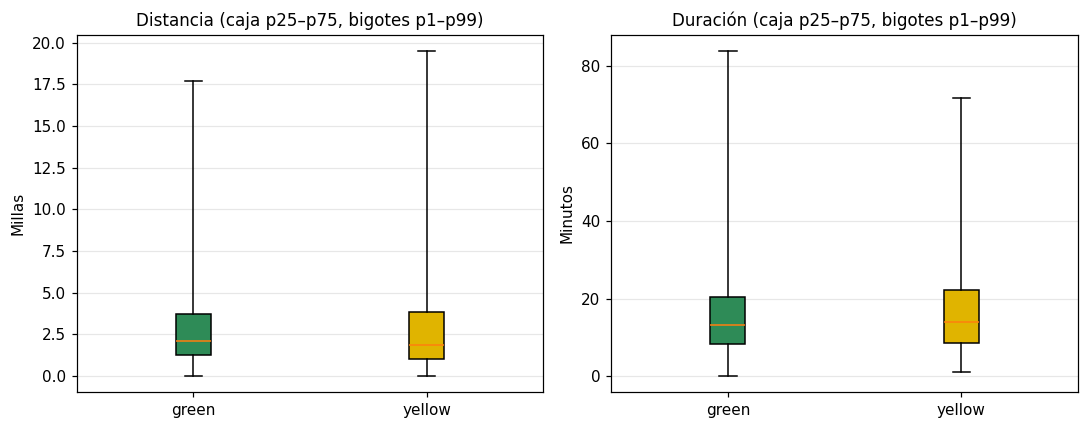

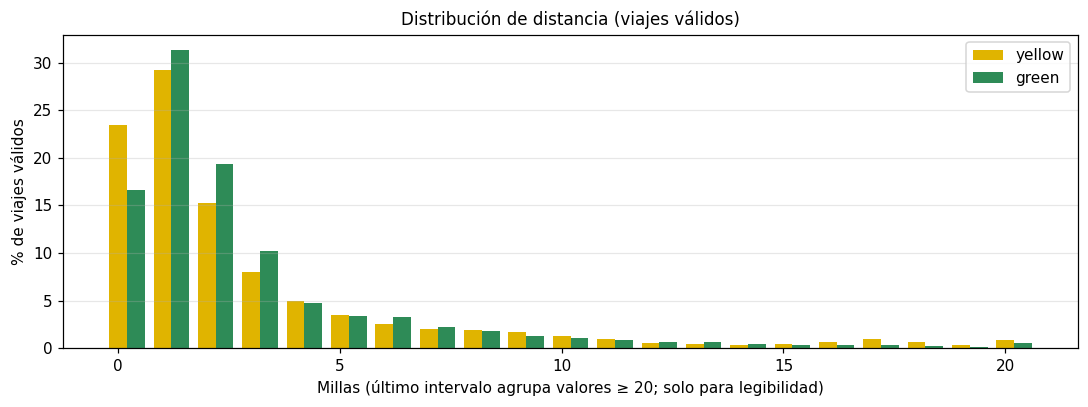

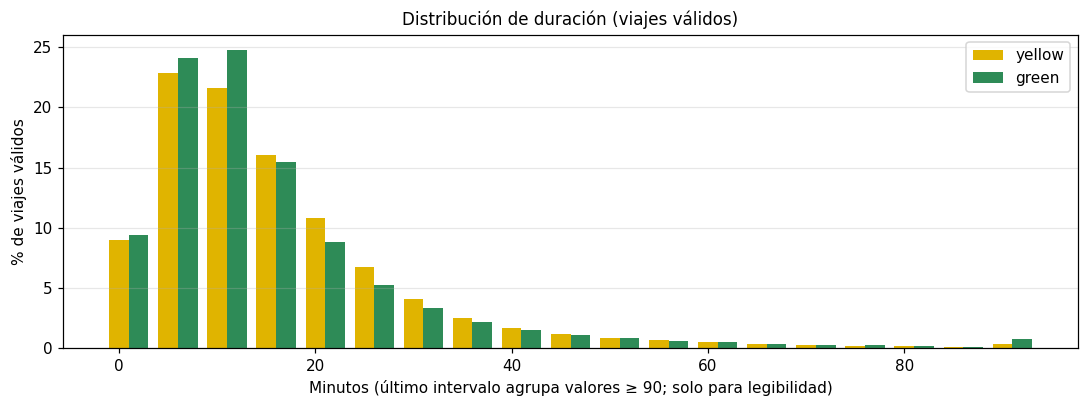

In [18]:
mostrar("resumen_distancia")
mostrar("resumen_duracion", ver_sql=False)
ep.plot_distancia_duracion(res)
plt.show()
ep.plot_hist(res["hist_distancia"], "Distribución de distancia (viajes válidos)", "Millas", 20, 1)
plt.show()
ep.plot_hist(res["hist_duracion"], "Distribución de duración (viajes válidos)", "Minutos", 90, 5)
plt.show()

**Interpretación:** la distancia mediana es 1.86 mi en yellow y 2.08 mi en green, pero la media de yellow (3.41) supera a la de green (3.25) por una cola más larga (p95 de 12.4 vs 10.5 mi). La duración mediana es 14.1 min en yellow y 13.1 en green. Green tiene una cola de duración más extrema (p99.9 = 1,404 min frente a 127 en yellow), señal de registros con el taxímetro abierto por horas, que siguen siendo menores a 24 h y por eso permanecen en `trips_valid`.

**Pregunta 6.** Distribución de `fare_amount` y `total_amount` en viajes válidos. `total_amount` incluye
recargos, peajes y propinas con tarjeta; no incluye propinas en efectivo.

SELECT taxi_type, 'fare_amount' AS metric, COUNT(fare_amount) AS n, AVG(fare_amount) AS mean, STDDEV_SAMP(fare_amount) AS std,
       MIN(fare_amount) AS min, approx_quantile(fare_amount, 0.01) AS p01, approx_quantile(fare_amount, 0.05) AS p05, approx_quantile(fare_amount, 0.25) AS p25, approx_quantile(fare_amount, 0.5) AS p50, approx_quantile(fare_amount, 0.75) AS p75, approx_quantile(fare_amount, 0.95) AS p95, approx_quantile(fare_amount, 0.99) AS p99, approx_quantile(fare_amount, 0.999) AS p999, MAX(fare_amount) AS max
FROM trips_valid WHERE source_year IN (2026) AND TRUE GROUP BY taxi_type ORDER BY taxi_type


,taxi_type,metric,n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,p999,max
0,green,fare_amount,334831,17.05,17.68,0.0,0.01,3.00,8.61,13.28,19.73,44.14,80.39,197.21,1676.7
1,yellow,fare_amount,29162994,21.56,18.23,0.0,4.31,5.87,10.08,15.93,26.64,59.74,81.62,158.11,1860.8


,taxi_type,metric,n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,p999,max
0,green,total_amount,334831,25.57,20.26,0.0,5.77,9.53,15.00,20.49,29.70,57.60,97.85,231.36,1678.20
1,yellow,total_amount,29162994,30.44,21.96,0.0,9.44,12.32,17.51,23.75,34.78,78.01,105.95,196.80,1884.55


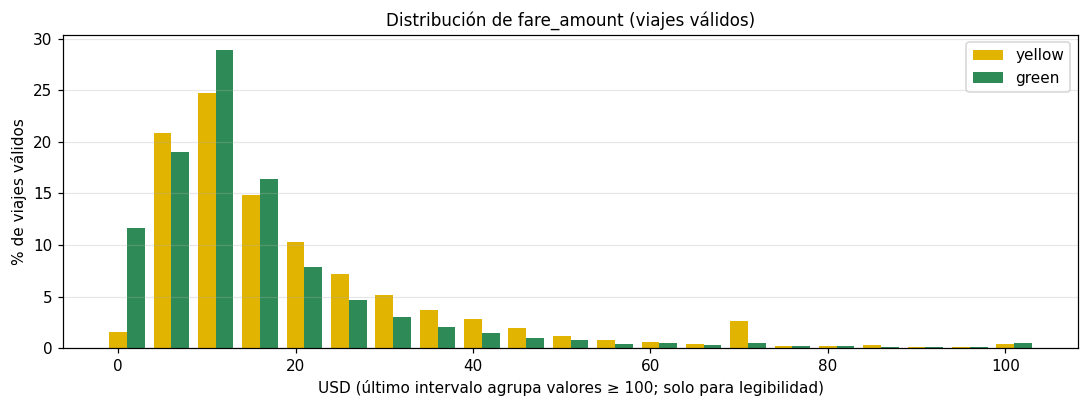

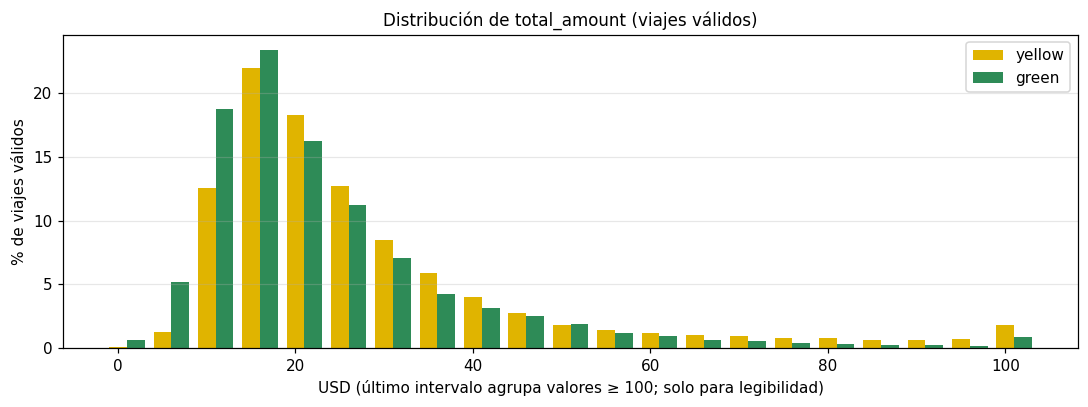

In [19]:
mostrar("resumen_fare")
mostrar("resumen_total", ver_sql=False)
ep.plot_hist(res["hist_fare"], "Distribución de fare_amount (viajes válidos)", "USD", 100, 5)
plt.show()
ep.plot_hist(res["hist_total"], "Distribución de total_amount (viajes válidos)", "USD", 100, 5)
plt.show()

**Interpretación:** la tarifa mediana es 15.96 USD (yellow) y 13.24 USD (green); el monto total mediano, 23.74 y 20.48 USD. Ambas distribuciones son asimétricas a la derecha (en yellow, media de 30.44 frente a mediana de 23.74) y tienen máximos superiores a 1,600 USD. Los histogramas agrupan los valores ≥ 100 USD solo para que se puedan leer; los extremos se documentan en la sección 15.

**Pregunta 7.** Relación entre distancia y tarifa. La correlación y la recta de mínimos cuadrados se
calculan en DuckDB sobre todos los viajes válidos con distancia y tarifa positivas. El hexbin usa una
**muestra controlada** de 20,000 viajes por tipo (`reservoir`, semilla 42), limitada a 30 millas y
150 USD solo para la gráfica.

SELECT taxi_type, COUNT(*) AS n, corr(trip_distance, fare_amount) AS corr,
       regr_slope(fare_amount, trip_distance) AS slope_usd_per_mile, regr_intercept(fare_amount, trip_distance) AS intercept_usd
FROM trips_valid WHERE source_year IN (2026) AND trip_distance > 0 AND fare_amount > 0 GROUP BY taxi_type ORDER BY taxi_type


,taxi_type,n,corr,slope_usd_per_mile,intercept_usd
0,green,318551,0.580,2.720,8.103
1,yellow,28223996,0.868,3.575,8.739


SELECT trip_distance, fare_amount FROM (
    SELECT trip_distance, fare_amount FROM trips_valid
    WHERE source_year IN (2026) AND taxi_type = 'yellow'
      AND trip_distance > 0 AND trip_distance <= 30 AND fare_amount > 0 AND fare_amount <= 150
) USING SAMPLE reservoir(20000 ROWS) REPEATABLE (42)


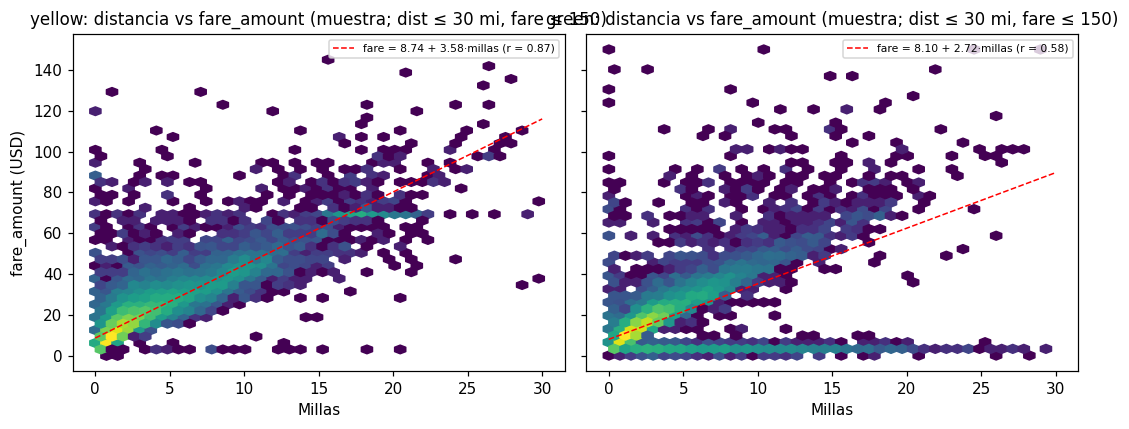

In [20]:
mostrar("distancia_vs_fare", redondeo=3)
print(lc.SQL_MUESTRA.format(years=lc.sql_years(YEARS_EDA), taxi="yellow"))
ep.plot_distancia_vs_fare(con_eda, res, YEARS_EDA)
plt.show()

**Interpretación:** la relación es casi lineal en yellow (r = 0.87; 3.58 USD por milla y un intercepto de 8.74 USD) y más débil en green (r = 0.58; 2.72 USD por milla). El hexbin de green muestra más viajes con tarifa alta para distancias cortas y tarifas planas, lo que indica más tarifas que no siguen el taxímetro estándar. La recta resume una asociación y no permite calcular la tarifa de un viaje individual.

### 13. Yellow vs green

Misma definición de métrica para ambos grupos: viajes válidos, medias y medianas exactas de DuckDB, y
porcentaje de tarjeta/efectivo sobre todos los viajes válidos de cada tipo.

SELECT taxi_type, COUNT(*) AS n_valid,
       AVG(trip_distance) AS dist_mean, median(trip_distance) AS dist_median,
       AVG(trip_minutes) AS min_mean, median(trip_minutes) AS min_median,
       AVG(fare_amount) AS fare_mean, median(fare_amount) AS fare_median,
       AVG(total_amount) AS total_mean, median(total_amount) AS total_median,
       100.0 * AVG((payment_type = 1)::INT) AS pct_tarjeta, 100.0 * AVG((payment_type = 2)::INT) AS pct_efectivo
FROM trips_valid WHERE source_year IN (2026) GROUP BY taxi_type ORDER BY taxi_type


,taxi_type,n_valid,dist_mean,dist_median,min_mean,min_median,fare_mean,fare_median,total_mean,total_median,pct_tarjeta,pct_efectivo
0,green,334831,3.25,2.08,20.90,13.13,17.05,13.50,25.57,20.50,76.57,22.93
1,yellow,29162994,3.41,1.87,17.88,14.12,21.56,16.04,30.44,23.75,63.83,9.00


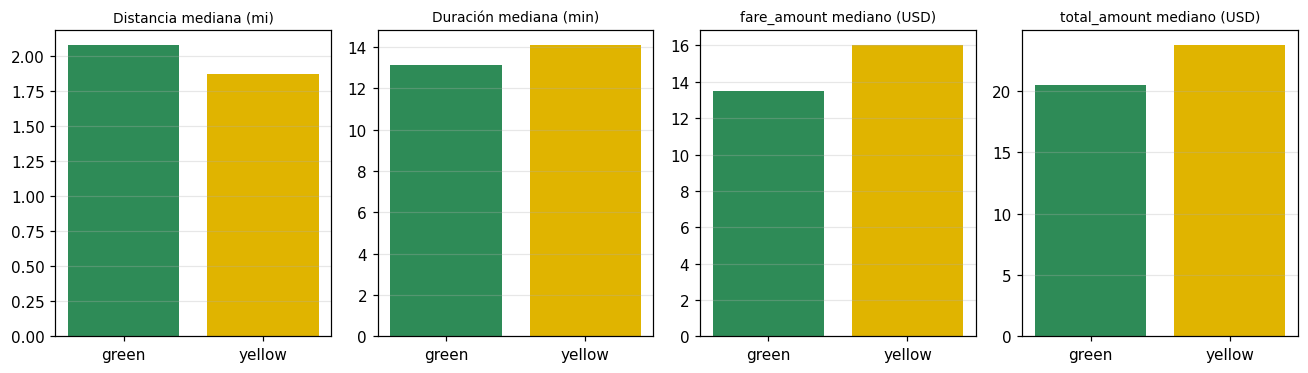

In [21]:
mostrar("comparacion")
ep.plot_comparacion(res["comparacion"])
plt.show()

**Interpretación:** con la misma definición de métrica, yellow tiene viajes algo más cortos en mediana (1.87 vs 2.08 mi) pero más largos en duración (14.1 vs 13.1 min) y más caros (total mediano 23.75 vs 20.50 USD). La diferencia más grande está en el pago: green usa efectivo en el 22.9 % de los viajes válidos y yellow en el 9.0 %. Parte de esa brecha proviene del bloque Flex Fare (código 0) de yellow, que no existe en green.

**Variables que no se comparan directamente** (diferencias de esquema o significado observadas en la sección de
columnas y en los Parquet de 2024–2026):

- `Airport_fee` solo existe en yellow; `ehail_fee` y `trip_type` solo existen en green.
- `payment_type = 0` (Flex Fare) aparece en yellow; en green el equivalente operativo no existe y los registros
  sin forma de pago llegan como `NULL`. Por eso el % de tarjeta/efectivo se interpreta con ese bloque en mente.
- `cbd_congestion_fee` solo existe desde 2025 y `request_source` solo en 2026; no se incluyen en la tabla
  normalizada porque no están en todos los años.
- Green opera principalmente fuera de Manhattan central y aeropuertos, así que las diferencias describen
  servicios distintos, no solo comportamientos distintos del pasajero.

### 14. Pagos y propinas

**Pregunta 8.** Distribución de `payment_type` sobre todos los registros. Las etiquetas siguen el diccionario
oficial de la TLC (*Data Dictionary – Yellow Taxi Trip Records*, 18-mar-2025): 0 = Flex Fare, 1 = tarjeta,
2 = efectivo, 3 = sin cargo, 4 = disputa, 5 = desconocido, 6 = anulado. `NULL` no tiene código.

SELECT taxi_type, payment_type, COUNT(*) AS n_trips,
       100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY taxi_type) AS pct
FROM trips_enriched WHERE source_year IN (2026)
GROUP BY taxi_type, payment_type ORDER BY taxi_type, payment_type


,taxi_type,payment_type,n_trips,pct
0,green,1.0,219980,65.25
1,green,2.0,65921,19.55
2,green,3.0,1688,0.50
3,green,4.0,750,0.22
4,green,NaN,48775,14.47
5,yellow,0.0,7716688,25.98
6,yellow,1.0,18941008,63.77
7,yellow,2.0,2708031,9.12
8,yellow,3.0,98138,0.33
9,yellow,4.0,239488,0.81


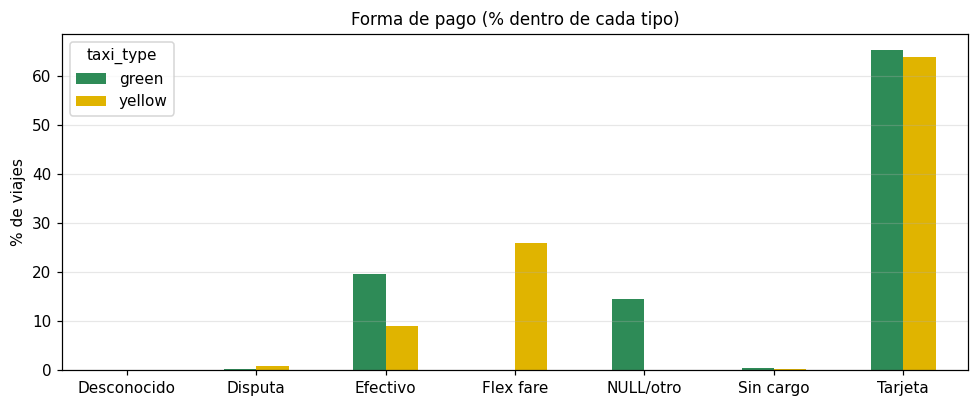

In [22]:
mostrar("pagos")
ep.plot_pagos(res["pagos"])
plt.show()

**Interpretación:** la tarjeta domina en ambos tipos (63.8 % yellow, 65.3 % green). Yellow tiene un 26.0 % de registros con código 0 (Flex Fare), y green un 14.5 % con `payment_type` nulo; ninguno de los dos bloques se reetiqueta. El efectivo pesa el doble en green (19.6 % frente a 9.1 %). Disputas y viajes sin cargo están por debajo del 1 %.

**Pregunta 9.** Propinas cuando el dato es aplicable: viajes válidos con tarjeta y `fare_amount > 0`.
La segunda tabla muestra por qué no se mezclan formas de pago: en efectivo la propina casi nunca queda registrada.

SELECT taxi_type, COUNT(*) AS n_aplicables, 100.0 * AVG((tip_amount > 0)::INT) AS pct_con_propina,
       AVG(tip_amount) AS mean_tip_usd, AVG(tip_percentage) AS mean_tip_pct,
       approx_quantile(tip_percentage, 0.25) AS p25_pct, approx_quantile(tip_percentage, 0.5) AS p50_pct,
       approx_quantile(tip_percentage, 0.75) AS p75_pct, approx_quantile(tip_percentage, 0.95) AS p95_pct,
       approx_quantile(tip_percentage, 0.99) AS p99_pct
FROM trips_valid WHERE source_year IN (2026) AND payment_type = 1 AND fare_amount > 0 GROUP BY taxi_type ORDER BY taxi_type


,taxi_type,n_aplicables,pct_con_propina,mean_tip_usd,mean_tip_pct,p25_pct,p50_pct,p75_pct,p95_pct,p99_pct
0,green,219143,90.54,3.84,25.60,17.07,23.50,27.96,37.67,59.04
1,yellow,18614449,91.01,4.28,25.39,18.68,26.38,31.53,42.32,56.53


,taxi_type,payment_type,n_trips,pct_tip_gt0
0,green,1.0,219144,90.54
1,green,2.0,65616,0.00
2,green,3.0,1023,1.56
3,green,4.0,424,0.24
4,green,NaN,48624,16.09
5,yellow,0.0,7713572,8.14
6,yellow,1.0,18614595,91.01
7,yellow,2.0,2623481,0.01
8,yellow,3.0,76877,0.04
9,yellow,4.0,134467,0.03


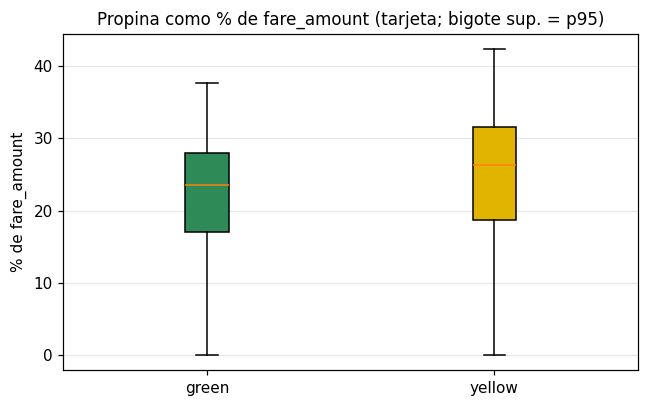

In [23]:
mostrar("propinas")
mostrar("propina_por_pago", ver_sql=False)
ep.plot_propinas(res["propinas"])
plt.show()

**Interpretación:** entre viajes válidos con tarjeta y tarifa positiva, el 91.0 % (yellow) y el 90.5 % (green) registran propina; la propina mediana es 26.4 % y 23.5 % de la tarifa (p75 de 31.5 % y 28.0 %). La tabla por forma de pago confirma que en efectivo la propina prácticamente no se registra, por eso no se mezcla con tarjeta: hacerlo bajaría artificialmente la propina típica.

### 15. Distribuciones y outliers

**Pregunta 10.** Percentiles y extremos **sin filtrar** (`trips_enriched`). Se combinan reglas de dominio
(velocidad > 100 mph, duración > 24 h, valores negativos) con percentiles observados. Un valor sobre p99 no se
elimina por sí solo; se documenta.

In [24]:
mostrar("extremos_sin_filtrar")

SELECT taxi_type, 'trip_distance' AS metric, COUNT(trip_distance) AS n, AVG(trip_distance) AS mean, STDDEV_SAMP(trip_distance) AS std,
       MIN(trip_distance) AS min, approx_quantile(trip_distance, 0.01) AS p01, approx_quantile(trip_distance, 0.05) AS p05, approx_quantile(trip_distance, 0.25) AS p25, approx_quantile(trip_distance, 0.5) AS p50, approx_quantile(trip_distance, 0.75) AS p75, approx_quantile(trip_distance, 0.95) AS p95, approx_quantile(trip_distance, 0.99) AS p99, approx_quantile(trip_distance, 0.999) AS p999, MAX(trip_distance) AS max
FROM trips_enriched WHERE source_year IN (2026) AND TRUE GROUP BY taxi_type
UNION ALL
SELECT taxi_type, 'trip_minutes' AS metric, COUNT(trip_minutes) AS n, AVG(trip_minutes) AS mean, STDDEV_SAMP(trip_minutes) AS std,
       MIN(trip_minutes) AS min, approx_quantile(trip_minutes, 0.01) AS p01, approx_quantile(trip_minutes, 0.05) AS p05, approx_quantile(trip_minutes, 0.25) AS p25, approx_quantile(trip_minutes, 0.5) AS p50, approx_quantile(tri

,taxi_type,metric,n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,p999,max
0,green,trip_distance,337114,13.35,880.40,0.00,0.00,0.21,1.25,2.07,3.69,10.63,17.79,273.47,179830.92
1,yellow,trip_distance,29703355,5.55,550.65,0.00,0.00,0.30,1.02,1.85,3.81,12.39,19.54,46.18,328522.20
2,green,trip_minutes,337114,20.80,73.67,-687.00,0.07,2.85,8.31,13.07,20.44,44.75,83.65,1404.53,2456.37
3,yellow,trip_minutes,29703355,17.64,78.14,-300517.52,0.01,3.32,8.33,13.94,22.14,43.71,71.33,161.65,17165.42
4,yellow,fare_amount,29703355,21.26,18.96,-2555.20,3.18,5.80,10.02,15.82,26.44,59.48,81.47,161.27,7045.00
5,green,fare_amount,337114,17.01,17.96,-500.00,0.00,3.00,8.60,13.23,19.67,44.30,80.85,201.61,1676.70
6,green,total_amount,337114,25.49,20.55,-501.50,4.98,9.35,14.95,20.47,29.67,57.73,97.49,233.41,1678.20
7,yellow,total_amount,29703355,30.07,22.75,-2560.20,7.87,12.03,17.39,23.62,34.59,77.85,105.48,193.14,7053.50
8,green,avg_speed_mph,336880,50.04,3468.24,0.00,0.00,3.21,7.68,9.88,12.95,22.62,34.24,2740.50,980895.93
9,yellow,avg_speed_mph,29331672,19.56,2821.68,0.00,0.00,2.65,6.57,9.11,12.75,23.94,34.43,115.88,4816614.80


In [25]:
ext = res["extremos_sin_filtrar"].set_index(["taxi_type", "metric"])
dominio = {"trip_distance": None, "trip_minutes": lc.DURATION_LIMIT_MIN, "fare_amount": None,
           "total_amount": None, "avg_speed_mph": lc.SPEED_THRESHOLD_MPH}
tabla = ext[["min", "p01", "p50", "p99", "p999", "max"]].copy()
tabla["umbral_dominio"] = [dominio[m] for _, m in tabla.index]
display(tabla.round(2))

min   p01    p50     p99     p999         max  umbral_dominio
taxi_type metric                                                                            
green     trip_distance       0.00  0.00   2.07   17.79   273.47   179830.92             NaN
yellow    trip_distance       0.00  0.00   1.85   19.54    46.18   328522.20             NaN
green     trip_minutes     -687.00  0.07  13.07   83.65  1404.53     2456.37          1440.0
yellow    trip_minutes  -300517.52  0.01  13.94   71.33   161.65    17165.42          1440.0
          fare_amount     -2555.20  3.18  15.82   81.47   161.27     7045.00             NaN
green     fare_amount      -500.00  0.00  13.23   80.85   201.61     1676.70             NaN
          total_amount     -501.50  4.98  20.47   97.49   233.41     1678.20             NaN
yellow    total_amount    -2560.20  7.87  23.62  105.48   193.14     7053.50             NaN
green     avg_speed_mph       0.00  0.00   9.88   34.24  2740.50   980895.93           100.0
yellow    avg_speed_mph       0.00  0.00   9.11   34.43   115.88  4816614.80           100.0

**Interpretación:** sin filtrar aparecen distancias de cientos de millas (incluso dentro de los válidos el máximo es 475 mi en yellow y 214 mi en green), duraciones negativas o cercanas a 24 h, tarifas y totales negativos y velocidades implícitas imposibles. El p99.9 queda muy lejos del máximo en todas las métricas, por eso conviene usar mediana y percentiles. Las reglas de dominio (velocidad > 100 mph, duración > 24 h, negativos) marcan los casos imposibles; los valores altos pero posibles se conservan.

**Preguntas 11 y 12.** `PULocationID` y `DOLocationID` con más viajes (15 primeros por tipo, todos los registros).

SELECT taxi_type, pu_location_id, COUNT(*) AS n_trips,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY taxi_type), 2) AS pct
FROM trips_enriched WHERE source_year IN (2026) AND pu_location_id IS NOT NULL
GROUP BY taxi_type, pu_location_id
QUALIFY ROW_NUMBER() OVER (PARTITION BY taxi_type ORDER BY COUNT(*) DESC) <= 15
ORDER BY taxi_type, n_trips DESC


pu_location_id           pct       
taxi_type          green yellow  green yellow
rank                                         
1                   74.0  237.0  26.22   4.40
2                   75.0  161.0  12.79   4.12
3                   95.0  132.0   4.80   3.98
4                   43.0  236.0   3.94   3.93
5                  166.0  186.0   3.77   3.04
6                   82.0  162.0   3.52   3.04
7                   41.0  230.0   3.39   2.87
8                   65.0  142.0   3.19   2.85
9                  130.0   79.0   2.84   2.66
10                  97.0  170.0   2.65   2.61

do_location_id          pct       
taxi_type          green yellow green yellow
rank                                        
1                   75.0  236.0  5.96   4.04
2                  236.0  237.0  5.26   3.96
3                   74.0  161.0  4.55   3.40
4                  238.0  170.0  3.72   2.75
5                  166.0  230.0  3.20   2.74
6                   41.0  162.0  3.11   2.60
7                   42.0  239.0  2.82   2.56
8                  263.0  142.0  2.73   2.55
9                  138.0   68.0  2.52   2.49
10                 239.0  141.0  2.28   2.48

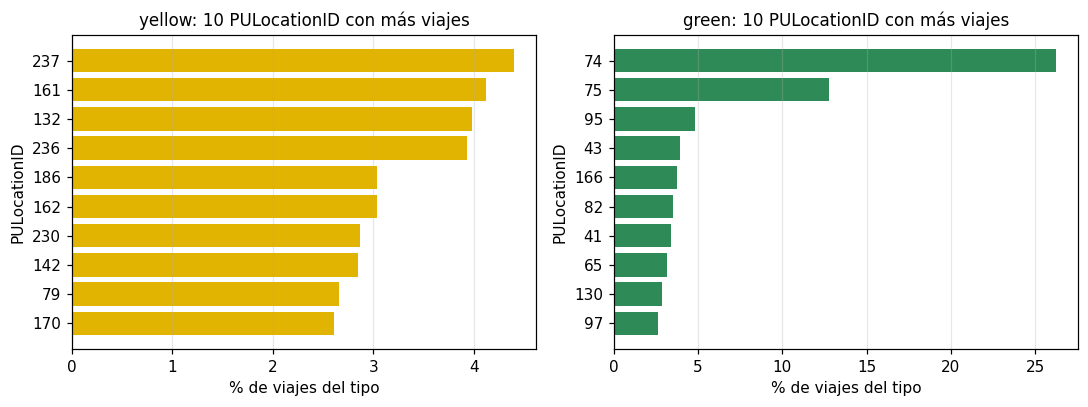

In [26]:
top = res["top_pu"].assign(rank=lambda d: d.groupby("taxi_type").cumcount() + 1)
top_do = res["top_do"].assign(rank=lambda d: d.groupby("taxi_type").cumcount() + 1)
print(lc.EDA_QUERIES["top_pu"].format(years=lc.sql_years(YEARS_EDA)))
display(top.pivot(index="rank", columns="taxi_type", values=["pu_location_id", "pct"]).head(10))
display(top_do.pivot(index="rank", columns="taxi_type", values=["do_location_id", "pct"]).head(10))

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, taxi in zip(axs, lc.TAXIS):
    d = top[top.taxi_type == taxi].head(10)
    ax.barh(d.pu_location_id.astype(str), d.pct, color=lc.COLOR[taxi])
    ax.invert_yaxis(); ax.set(title=f"{taxi}: 10 PULocationID con más viajes", xlabel="% de viajes del tipo", ylabel="PULocationID")
    ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

**Interpretación:** green está mucho más concentrado: los PULocationID 74 y 75 encabezan sus pickups y los 10 primeros reúnen alrededor de dos tercios (67 % en 2026). Yellow está más disperso: sus IDs principales (132, 237, 161, 236) rondan el 4–5 % cada uno. En los drop-offs se repite la diferencia, aunque más atenuada. No se asignan nombres porque el proyecto no incluye el catálogo de zonas.

### Hallazgos relevantes

1. **Yellow y green atienden patrones de demanda distintos.** Ambos tienen el pico horario a las 18 h, pero green cae en fin de semana (1,101 viajes/día el domingo frente a 1,590 el jueves) mientras que yellow mantiene un sábado casi tan alto como el jueves (132,375 vs 135,471). *Basado en el promedio por día calendario de enero–agosto de 2026; con el año incompleto, el patrón podría variar en los meses restantes.*
2. **Green está geográficamente concentrado.** Los PULocationID 74 y 75 son los dos primeros y los 10 primeros reúnen el 67 % de sus pickups, mientras que el ID más frecuente de yellow no llega al 5 %. *Solo IDs, sin catálogo de zonas; enero–agosto de 2026.*
3. **La tarifa de yellow sigue la distancia mucho más de cerca que la de green.** r = 0.87 y 3.58 USD por milla en yellow frente a r = 0.58 y 2.72 USD por milla en green (viajes válidos con distancia y tarifa positivas). Esto describe una asociación; no prueba cuál tarifa se aplicó en cada viaje.
4. **La forma de pago no es comparable directamente entre tipos.** El 26 % de los registros yellow tienen código 0 (Flex Fare) y el 14.5 % de los green tienen `payment_type` nulo. Entre los pagos con código conocido, green usa efectivo el doble que yellow (19.6 % vs 9.1 %). Donde la propina es aplicable (tarjeta), ~91 % de los viajes la registran en ambos tipos.

## 17. Incorporación de 2024

`scripts/download_data.py` quedó parametrizado por año. Su API interna es:

```python
construir_nombre(tipo, anio, mes)   # yellow_tripdata_2024-01.parquet
construir_url(tipo, anio, mes)      # https://d37ci6vzurychx.cloudfront.net/trip-data/<archivo>
ruta_destino(tipo, anio, mes)       # data/raw/<tipo>/<anio>/<archivo>
descargar(tipo, anio)               # baja solo meses publicados que falten
verificar(tipo, anio)               # compara meses publicados (HEAD) con archivos locales
```

CLI:

```bash
python scripts/download_data.py --years 2024 2026
python scripts/download_data.py --years 2024 --taxi yellow
python scripts/download_data.py --verify --years 2024 2026
```

La disponibilidad se consulta en la fuente con una petición `HEAD` por mes; no se asume "12 archivos = completo".
Un archivo local no vacío nunca se vuelve a descargar y la descarga se hace a un temporal `.part` que solo se
renombra al terminar. A continuación se ejecuta `descargar(tipo, 2024)` y se compara el estado de los archivos
de 2026 antes y después.

In [27]:
def inventario_archivos(years):
    """Archivos Parquet locales con tamaño y fecha de modificación (UTC dentro del contenedor)."""
    filas = []
    for t in lc.TAXIS:
        for y in years:
            for p in sorted((lc.DATA_RAW / t / str(y)).glob("*.parquet")):
                st = p.stat()
                filas.append(dict(taxi_type=t, source_year=y, file=p.name, size_bytes=st.st_size,
                                  modified=pd.Timestamp(st.st_mtime, unit="s").floor("s")))
    return pd.DataFrame(filas)


def resumen_descarga(statuses):
    d = pd.DataFrame([dict(taxi_type=s.taxi_type, year=s.year, published=s.published, downloaded=s.downloaded,
                           skipped_existing=s.skipped_existing, failed=s.failed) for s in statuses])
    return d.groupby(["taxi_type", "year"]).sum().astype(int)


antes_2026 = inventario_archivos([2026])
statuses_2024 = [s for t in lc.TAXIS for s in download_data.descargar(t, 2024, PROJECT_ROOT)]
display(resumen_descarga(statuses_2024))

despues_2026 = inventario_archivos([2026])
assert antes_2026.equals(despues_2026), "los archivos de 2026 cambiaron"
print(f"2026 intacto: {len(despues_2026)} archivos con el mismo tamaño y fecha de modificación")

linea = inventario_archivos([2024, 2026]).groupby(["taxi_type", "source_year"]).agg(
    files=("file", "count"), size_mb=("size_bytes", lambda s: round(s.sum() / 2**20, 1)),
    first_download=("modified", "min"), last_download=("modified", "max"))
display(linea)

,,published,downloaded,skipped_existing,failed
taxi_type,year,,,,
green,2024,12,0,12,0
yellow,2024,12,0,12,0


2026 intacto: 16 archivos con el mismo tamaño y fecha de modificación


files  size_mb      first_download       last_download
taxi_type source_year                                                        
green     2024            12     15.2 2026-10-07 05:11:16 2026-10-07 05:11:18
          2026             8      7.9 2026-10-07 05:10:00 2026-10-07 05:10:01
yellow    2024            12    660.9 2026-10-07 05:10:18 2026-10-07 05:11:15
          2026             8    487.8 2026-10-07 05:09:19 2026-10-07 05:09:59

**Interpretación:** la llamada a `descargar(tipo, 2024)` encontró los 12 meses publicados de ambos tipos y los reportó como existentes (0 descargas nuevas en esta ejecución del notebook). Las fechas de modificación muestran el orden real de incorporación: 2026 se descargó primero (05:09–05:10 UTC) y 2024 después (05:10–05:11 UTC). Los 16 archivos de 2026 conservan tamaño y fecha antes y después: la incorporación de 2024 no tocó 2026.

In [28]:
def tabla_verificacion(years):
    """verificar(tipo, anio) para cada combinación: meses publicados vs locales válidos."""
    filas = []
    for y in years:
        for t in lc.TAXIS:
            st = download_data.verificar(t, y, PROJECT_ROOT)
            pub = [s.month for s in st if s.published]
            loc = [s.month for s in st if s.published and s.local_exists]
            filas.append(dict(taxi_type=t, source_year=y, published=len(pub), local_valid=len(loc),
                              missing=sorted(set(pub) - set(loc)), months=f"{min(pub)}–{max(pub)}" if pub else "-",
                              status="COMPLETO" if pub and set(pub) == set(loc) else "INCOMPLETO"))
    return pd.DataFrame(filas)


display(tabla_verificacion([2024, 2026]))

,taxi_type,source_year,published,local_valid,missing,months,status
0,yellow,2024,12,12,[],1–12,COMPLETO
1,green,2024,12,12,[],1–12,COMPLETO
2,yellow,2026,8,8,[],1–8,COMPLETO
3,green,2026,8,8,[],1–8,COMPLETO


## 18. Validación incremental

Una **única consulta DuckDB** recorre los dos años. La vista `trips` se genera con listas de patrones
(`data/raw/<tipo>/<anio>/*.parquet`), no con nombres de meses, y extrae `source_year`/`source_month` del
nombre del archivo fuente.

In [29]:
YEARS_2 = [2024, 2026]
con_24_26 = lc.conectar(YEARS_2)
print(lc.select_normalizado("yellow", YEARS_2).split("FROM", 1)[1].strip())

t0 = time.perf_counter()
val_2 = vy.tabla_validacion(con_24_26, YEARS_2)
print(f"Tabla de validación (una consulta sobre {YEARS_2}) en {time.perf_counter() - t0:.1f} s")
display(val_2)

read_parquet(['/workspace/data/raw/yellow/2024/*.parquet', '/workspace/data/raw/yellow/2026/*.parquet'], filename = true, union_by_name = true)


Tabla de validación (una consulta sobre [2024, 2026]) en 0.4 s


,taxi_type,source_year,available_files,record_count,first_month,last_month,size_mb
0,yellow,2024,12,41169720,1,12,660.90
1,yellow,2026,8,29703355,1,8,487.76
2,green,2024,12,660218,1,12,15.18
3,green,2026,8,337114,1,8,7.89


In [30]:
# No regresión: los resultados de 2026 son idénticos calculados solos o junto con 2024
mensual_2 = lc.q(con_24_26, "volumen_mensual", YEARS_2)
chk = res["volumen_mensual"].merge(mensual_2[mensual_2.source_year == 2026],
                                   on=["source_year", "source_month", "taxi_type"], suffixes=("_solo", "_junto"))
assert len(chk) == len(res["volumen_mensual"]) and (chk.n_trips_solo == chk.n_trips_junto).all()
comp_2 = lc.q(con_24_26, "comparacion", YEARS_2)
print("No regresión OK: conteos mensuales de 2026 idénticos solos y junto con 2024")
display(comp_2.round(2))

No regresión OK: conteos mensuales de 2026 idénticos solos y junto con 2024


,taxi_type,n_valid,dist_mean,dist_median,min_mean,min_median,fare_mean,fare_median,total_mean,total_median,pct_tarjeta,pct_efectivo
0,green,990316,2.95,1.94,20.13,12.33,17.96,13.5,24.77,19.68,73.28,26.15
1,yellow,69573128,3.38,1.80,17.66,13.48,20.63,14.9,29.46,22.20,70.51,11.51


**Interpretación:** una sola consulta sobre los patrones de 2024 y 2026 devuelve las cuatro combinaciones: yellow 2024 tiene 41,169,720 registros en 12 archivos (660.9 MB), green 2024 660,218 (15.2 MB), yellow 2026 29,703,355 en 8 archivos y green 2026 337,114. Los conteos mensuales de 2026 son idénticos calculados solos o junto con 2024. Con los dos años, la comparación yellow vs green mantiene las diferencias del EDA (total mediano 22.20 vs 19.68 USD; efectivo 11.5 % vs 26.2 %).

### Diseño preparado para crecimiento

Agregar un año nuevo requiere cambios pequeños porque:

- **Estructura de carpetas regular:** `data/raw/<tipo>/<anio>/`.
- **Nombres predecibles:** `<tipo>_tripdata_<anio>-<mes>.parquet`, igual que en la fuente.
- **Script parametrizado por año:** `--years` acepta cualquier lista; cada año se descarga y verifica por separado.
- **Consulta Parquet basada en patrones:** cada año aporta un glob `.../<anio>/*.parquet`.
- **`union_by_name = true`:** columnas nuevas (`cbd_congestion_fee` en 2025, `request_source` en 2026) o con otro
  orden no rompen la lectura.
- **Vista analítica normalizada:** nombres y tipos explícitos (`tpep_*`/`lpep_*` → `pickup_datetime`/`dropoff_datetime`).
- **Año y mes extraídos de la fuente:** `source_year` y `source_month` salen del nombre del archivo, no del pickup.
- **Consultas filtradas por `source_year`:** el EDA, el benchmark y los indicadores reciben la lista de años
  como parámetro; `lab8_common.anios_disponibles()` descubre los años presentes en disco.

## 19. Materialización en DuckDB

Se crea la base persistente `data/processed/lab8.duckdb` (ignorada por `.gitignore`) con la tabla `trips`:
las columnas normalizadas de 2024 y 2026 más `source_file`, `source_year` y `source_month`. Las variables
derivadas no se duplican en la tabla: se guardan como **vistas persistentes** `trips_enriched` y `trips_valid`
con la misma definición del EDA, para que Metabase y los indicadores las reutilicen.

El proceso es idempotente (`CREATE OR REPLACE TABLE` / `CREATE OR REPLACE VIEW`) y la conexión de escritura
se cierra al terminar para no bloquear el archivo a Metabase. El tiempo de creación se reporta como métrica
separada y no se suma al benchmark.

In [31]:
seg_2, total_2, por_anio_2, por_taxi_2 = mat.materializar(YEARS_2)
size_db_2 = lc.DB_PATH.stat().st_size / 2**20
size_pq_2 = val_2.size_mb.sum()
print(f"Tiempo de materialización (métrica separada): {seg_2:.1f} s")
print(f"Filas en trips: {total_2:,}")
print(f"lab8.duckdb: {size_db_2:,.1f} MB | Parquet {YEARS_2}: {size_pq_2:,.1f} MB")
display(por_anio_2); display(por_taxi_2)

# La conexión de escritura ya se cerró: se puede abrir en solo lectura sin bloqueo
with lc.nueva_conexion(lc.DB_PATH, read_only=True) as ro:
    display(ro.execute("SELECT table_name, table_type FROM information_schema.tables ORDER BY 1").fetchdf())
    assert ro.execute("SELECT COUNT(*) FROM trips").fetchone()[0] == val_2.record_count.sum()
print("Conteo de la tabla = conteo directo sobre Parquet")

Tiempo de materialización (métrica separada): 15.3 s
Filas en trips: 71,870,407
lab8.duckdb: 2,947.5 MB | Parquet [2024, 2026]: 1,171.7 MB


,source_year,n_rows
0,2024,41829938
1,2026,30040469


,taxi_type,n_rows
0,green,997332
1,yellow,70873075


,table_name,table_type
0,trips,BASE TABLE
1,trips_enriched,VIEW
2,trips_valid,VIEW


Conteo de la tabla = conteo directo sobre Parquet


**Interpretación:** la tabla `trips` quedó con 71,870,407 filas (41,829,938 de 2024 y 30,040,469 de 2026), igual a la consulta directa sobre Parquet, y se creó en 15.3 s, un costo que se reporta aparte del benchmark. El archivo mide 2,947.5 MB, pero esa cifra incluye bloques de la versión anterior de la tabla que DuckDB no compacta al hacer `CREATE OR REPLACE`; construida desde cero en esta misma sesión, la base de 2024+2026 medía 1,446 MB, frente a 1,171.7 MB de los Parquet. Materializar duplica los datos en disco.

## Benchmark: Parquet vs tabla materializada

### 20. Diseño

Se comparan dos fuentes con **el mismo cuerpo SQL**: ambas exponen una relación `scope` con las mismas columnas.

- **Parquet directo:** `scope` = vista normalizada sobre `read_parquet([...])` con solo los archivos de los años del escenario.
- **Tabla DuckDB:** `scope` = `SELECT * FROM trips WHERE source_year IN (...)` en `lab8.duckdb` (solo lectura).

| Consulta | Qué mide |
|---|---|
| `q1_conteo_taxi_anio` | `COUNT(*)` por tipo y año |
| `q2_mensual` | agregación temporal mensual (conteo y suma de `total_amount`) |
| `q3_taxi_media_mediana` | por tipo: promedio de distancia y **mediana** de tarifa |
| `q4_pago_filtrado` | filtros (marzo–junio, distancia y total > 0) y agrupación por forma de pago |
| `q5_hora_taxi` | agrupación por tipo y hora del pickup con promedio de distancia |

**Escenarios de cantidad de datos:** solo 2024 (12 meses), solo 2026 (**parcial: enero–agosto**) y 2024+2026.
La cantidad se controla con archivos/años, nunca con `LIMIT`.

**Metodología** (`scripts/benchmark.py`): para cada combinación consulta × fuente × escenario se verifica primero
que ambas fuentes devuelvan el mismo resultado (`assert_frame_equal`, no cronometrado), luego 1 ejecución de
calentamiento no registrada y 5 ejecuciones medidas con `time.perf_counter()`; el cronómetro se detiene después
de `fetchall()`. El orden entre fuentes se alterna en cada repetición. Ambas conexiones usan el mismo número de
hilos y la misma configuración. No se incluye descarga ni creación de la tabla.

**Sesgos posibles:** caché del sistema operativo (los Parquet y la base quedan en memoria tras el calentamiento),
caché interna de DuckDB, orden de ejecución, tamaño del resultado, número de hilos y hardware del equipo. Los
tiempos describen este ambiente; no son una verdad universal.

In [32]:
print("Ejemplo de par equivalente (q4, escenario 2026)\n-- Parquet directo")
print(bench.sql_fuente("parquet", [2026], bench.BENCH_QUERIES["q4_pago_filtrado"]))
print("\n-- Tabla materializada")
print(bench.sql_fuente("duckdb_table", [2026], bench.BENCH_QUERIES["q4_pago_filtrado"]))

Ejemplo de par equivalente (q4, escenario 2026)
-- Parquet directo
WITH scope AS (
SELECT
    'yellow' AS taxi_type,
    CAST(tpep_pickup_datetime AS TIMESTAMP) AS pickup_datetime,
    CAST(tpep_dropoff_datetime AS TIMESTAMP) AS dropoff_datetime,
    TRY_CAST(passenger_count AS INTEGER) AS passenger_count,
    CAST(trip_distance AS DOUBLE) AS trip_distance,
    CAST(PULocationID AS INTEGER) AS pu_location_id,
    CAST(DOLocationID AS INTEGER) AS do_location_id,
    TRY_CAST(payment_type AS INTEGER) AS payment_type,
    CAST(fare_amount AS DOUBLE) AS fare_amount,
    CAST(tip_amount AS DOUBLE) AS tip_amount,
    CAST(tolls_amount AS DOUBLE) AS tolls_amount,
    CAST(total_amount AS DOUBLE) AS total_amount,
    parse_filename(filename) AS source_file,
    CAST(regexp_extract(filename, '_(\d{4})-(\d{2})\.parquet$', 1) AS INTEGER) AS source_year,
    CAST(regexp_extract(filename, '_(\d{4})-(\d{2})\.parquet$', 2) AS INTEGER) AS source_month
FROM read_parquet(['/workspace/data/raw/yellow/202

In [33]:
import platform

print(f"CPU lógicas: {os.cpu_count()} | hilos DuckDB: {lc.THREADS} | DuckDB {duckdb.__version__} | {platform.platform()}")
t0 = time.perf_counter()
bench_runs, bench_summary = bench.correr(repeats=5)
print(f"Benchmark completo en {time.perf_counter() - t0:.0f} s")
display(bench_runs.head(10))
display(bench_summary)

CPU lógicas: 8 | hilos DuckDB: 8 | DuckDB 1.1.3 | Linux-7.1.5-76070105-generic-x86_64-with-glibc2.41
threads = 8 (ambas conexiones) | 5 repeticiones + 1 calentamiento
  2024       q1_conteo_taxi_anio


  2024       q2_mensual


  2024       q3_taxi_media_mediana


  2024       q4_pago_filtrado


  2024       q5_hora_taxi


...

  2024+2026  q4_pago_filtrado


  2024+2026  q5_hora_taxi


Benchmark completo en 132 s


,query_name,source,data_scope,run,elapsed_ms,result_rows
0,q1_conteo_taxi_anio,parquet,2024,1,107.055909,2
1,q1_conteo_taxi_anio,duckdb_table,2024,1,202.175712,2
2,q1_conteo_taxi_anio,duckdb_table,2024,2,204.992533,2
3,q1_conteo_taxi_anio,parquet,2024,2,112.568455,2
4,q1_conteo_taxi_anio,parquet,2024,3,115.676885,2
5,q1_conteo_taxi_anio,duckdb_table,2024,3,212.353820,2
6,q1_conteo_taxi_anio,duckdb_table,2024,4,243.611675,2
7,q1_conteo_taxi_anio,parquet,2024,4,121.116060,2
8,q1_conteo_taxi_anio,parquet,2024,5,111.041763,2
9,q1_conteo_taxi_anio,duckdb_table,2024,5,213.796713,2


,query_name,source,data_scope,runs,median_ms,mean_ms,std_ms,min_ms,max_ms
0,q1_conteo_taxi_anio,duckdb_table,2024,5,212.35,215.39,16.51,202.18,243.61
1,q1_conteo_taxi_anio,duckdb_table,2024+2026,5,368.83,370.45,4.12,366.82,375.87
2,q1_conteo_taxi_anio,duckdb_table,2026,5,149.50,151.39,3.61,147.73,155.87
3,q1_conteo_taxi_anio,parquet,2024,5,112.57,113.49,5.27,107.06,121.12
4,q1_conteo_taxi_anio,parquet,2024+2026,5,182.47,181.59,1.89,178.91,183.53
5,q1_conteo_taxi_anio,parquet,2026,5,80.86,81.83,3.97,78.31,88.57
6,q2_mensual,duckdb_table,2024,5,87.85,89.97,6.24,84.25,99.15
7,q2_mensual,duckdb_table,2024+2026,5,169.46,168.75,2.38,164.81,170.98
8,q2_mensual,duckdb_table,2026,5,64.88,64.55,2.91,60.42,67.90
9,q2_mensual,parquet,2024,5,228.86,232.17,9.20,221.21,243.95


Resumen guardado en docs/benchmark_results.csv


source                            duckdb_table  parquet  parquet / tabla
data_scope query_name                                                   
2024       q1_conteo_taxi_anio           212.4    112.6              0.5
           q2_mensual                     87.8    228.9              2.6
           q3_taxi_media_mediana        1169.2   1174.0              1.0
           q4_pago_filtrado              312.0    799.8              2.6
           q5_hora_taxi                  325.1    505.6              1.6
2024+2026  q1_conteo_taxi_anio           368.8    182.5              0.5
           q2_mensual                    169.5    384.4              2.3
           q3_taxi_media_mediana        1748.4   1855.5              1.1
           q4_pago_filtrado              539.4   1342.1              2.5
           q5_hora_taxi                  587.6    867.5              1.5
2026       q1_conteo_taxi_anio           149.5     80.9              0.5
           q2_mensual                     64.9    169.9              2.6
           q3_taxi_media_mediana        1407.8   1425.5              1.0
           q4_pago_filtrado              509.3   1114.2              2.2
           q5_hora_taxi                  238.5    372.6              1.6

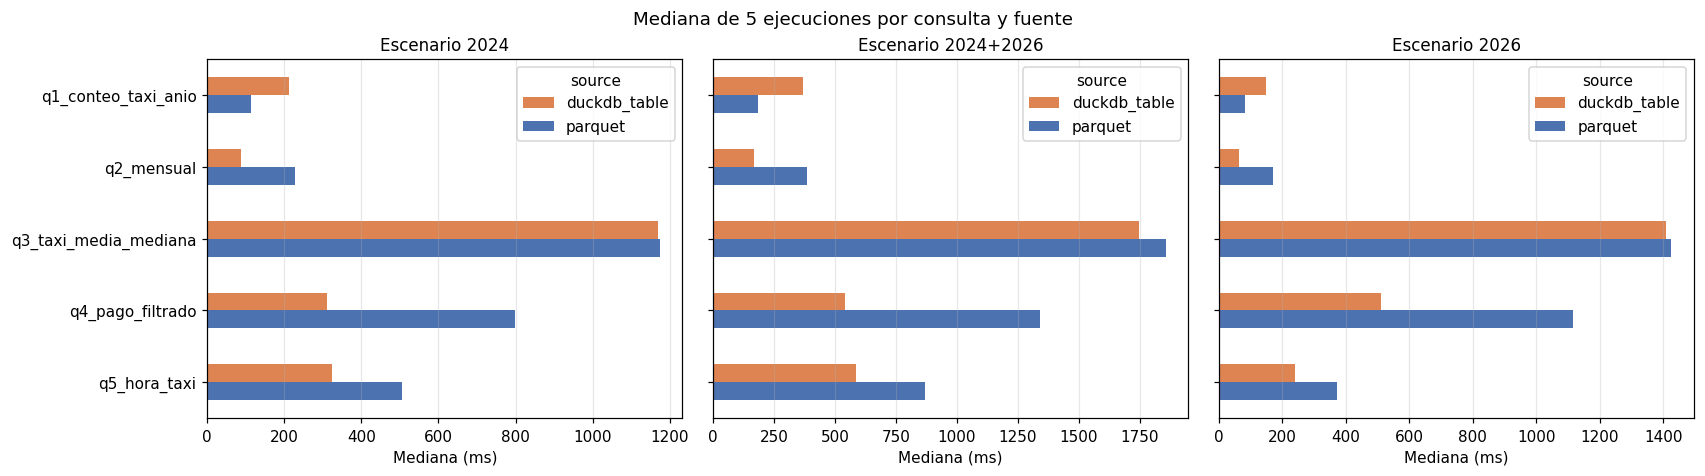

In [34]:
bench_summary.to_csv(lc.DOCS_DIR / "benchmark_results.csv", index=False)
print("Resumen guardado en docs/benchmark_results.csv")

razon = bench_summary.pivot_table(index=["data_scope", "query_name"], columns="source", values="median_ms")
razon["parquet / tabla"] = (razon["parquet"] / razon["duckdb_table"]).round(2)   # > 1: tabla más rápida
display(razon.round(1))

bench.plot_resumen(bench_summary)
plt.suptitle("Mediana de 5 ejecuciones por consulta y fuente", y=1.02)
plt.show()

### 21. Interpretación del benchmark

- **Parquet fue más rápido en el conteo (q1):** 112.6 ms frente a 212.4 ms en 2024 y 182.5 frente a 368.8 ms en 2024+2026 (razón Parquet/tabla ≈ 0.5). DuckDB responde `COUNT(*)` por grupo usando la metadata de los row groups y el nombre del archivo, mientras que la tabla tiene que recorrer las columnas `taxi_type` y `source_year`.
- **Prácticamente empate en la consulta con mediana (q3):** 1,174 vs 1,169 ms en 2024 y 1,855 vs 1,748 ms en 2024+2026 (razón 1.0–1.1). El costo lo domina el cálculo exacto de la mediana, no la lectura.
- **La tabla fue mejor en agregaciones con más columnas y filtros:** q2 mensual 2.3–2.6 veces más rápida, q4 con filtros 2.2–2.6 veces y q5 por hora 1.5–1.6 veces. Aquí Parquet paga en cada ejecución la descompresión, los casts y la normalización yellow/green.
- **Al aumentar los datos**, los tiempos crecen de forma aproximadamente proporcional a las filas en ambas fuentes (q4 en Parquet: 1,114 ms con 30 M filas, 1,342 ms con 72 M y 2,090 ms con 121 M) y las razones se mantienen estables, así que la ventaja relativa no cambia con el tamaño en este rango.
- **Costo de materializar:** 15.3 s para 2024+2026 y 24.4 s para los tres años, más espacio adicional en disco y la necesidad de reconstruir la tabla cada vez que llegan datos. Con ~1 s ahorrado por consulta en q4, la tabla se amortiza después de unas pocas decenas de consultas.
- **Ventaja de no duplicar:** Parquet directo no requiere ETL ni espacio extra y siempre refleja los archivos más recientes.

**Cuándo conviene cada estrategia:** Parquet directo para exploración, consultas puntuales, conteos y datos que cambian seguido; tabla materializada cuando las mismas agregaciones se repiten muchas veces (tablero de Metabase, indicadores) y el esquema normalizado debe ser estable. Ninguna estrategia fue mejor en todas las consultas. Los resultados corresponden a este equipo (8 hilos, archivos en caché tras el calentamiento) y podrían cambiar con disco frío u otro hardware.

## 22. Incorporación incremental de 2025

El conjunto de años por defecto del script pasa a ser `2024 2025 2026`
(`python scripts/download_data.py` equivale a `--years 2024 2025 2026`). Se ejecuta la descarga de 2025 y se
comprueba que 2024 y 2026 no cambian.

In [35]:
print("Años por defecto del script:", download_data.DEFAULT_YEARS)
antes_prev = inventario_archivos([2024, 2026])
statuses_2025 = [s for t in lc.TAXIS for s in download_data.descargar(t, 2025, PROJECT_ROOT)]
display(resumen_descarga(statuses_2025))

despues_prev = inventario_archivos([2024, 2026])
assert antes_prev.equals(despues_prev), "los archivos de 2024 o 2026 cambiaron"
print(f"2024 y 2026 intactos: {len(despues_prev)} archivos con el mismo tamaño y fecha de modificación")

YEARS_3 = list(lc.anios_disponibles())
print("Años descubiertos en data/raw:", YEARS_3)
display(inventario_archivos(YEARS_3).groupby(["taxi_type", "source_year"]).agg(
    files=("file", "count"), size_mb=("size_bytes", lambda s: round(s.sum() / 2**20, 1)),
    first_download=("modified", "min"), last_download=("modified", "max")))
display(tabla_verificacion(YEARS_3))

Años por defecto del script: (2024, 2025, 2026)


,,published,downloaded,skipped_existing,failed
taxi_type,year,,,,
green,2025,12,0,12,0
yellow,2025,12,0,12,0


2024 y 2026 intactos: 40 archivos con el mismo tamaño y fecha de modificación
Años descubiertos en data/raw: [2024, 2025, 2026]


files  size_mb      first_download       last_download
taxi_type source_year                                                        
green     2024            12     15.2 2026-10-07 05:11:16 2026-10-07 05:11:18
          2025            12     13.8 2026-10-07 05:12:33 2026-10-07 05:12:35
          2026             8      7.9 2026-10-07 05:10:00 2026-10-07 05:10:01
yellow    2024            12    660.9 2026-10-07 05:10:18 2026-10-07 05:11:15
          2025            12    791.5 2026-10-07 05:11:25 2026-10-07 05:12:32
          2026             8    487.8 2026-10-07 05:09:19 2026-10-07 05:09:59

,taxi_type,source_year,published,local_valid,missing,months,status
0,yellow,2024,12,12,[],1–12,COMPLETO
1,green,2024,12,12,[],1–12,COMPLETO
2,yellow,2025,12,12,[],1–12,COMPLETO
3,green,2025,12,12,[],1–12,COMPLETO
4,yellow,2026,8,8,[],1–8,COMPLETO
5,green,2026,8,8,[],1–8,COMPLETO


**Interpretación:** 2025 tiene 12 de 12 meses publicados para yellow y green (791.5 MB y 13.8 MB). Las fechas confirman el orden incremental 2026 → 2024 → 2025 (2025 se descargó a las 05:11–05:12 UTC) y los 40 archivos de 2024 y 2026 quedaron intactos. La verificación por tipo y año da COMPLETO en las seis combinaciones; 2026 es completo respecto a lo publicado (enero–agosto).

### Reconstrucción de la tabla materializada

La tabla se recrea completa desde los Parquet (sin insertar filas a mano) con los años descubiertos.
Después se validan los conteos por año y tipo contra una consulta directa sobre Parquet.

In [36]:
seg_3, total_3, por_anio_3, por_taxi_3 = mat.materializar()      # años descubiertos: 2024, 2025, 2026
size_db_3 = lc.DB_PATH.stat().st_size / 2**20

con_all = lc.conectar(YEARS_3)                                     # Parquet directo, los tres años
val_3 = vy.tabla_validacion(con_all, YEARS_3)
with lc.nueva_conexion(lc.DB_PATH, read_only=True) as ro:
    tabla_3 = ro.execute("SELECT taxi_type, source_year, COUNT(*) AS table_rows FROM trips GROUP BY ALL").fetchdf()
chk3 = val_3.merge(tabla_3, on=["taxi_type", "source_year"])
assert (chk3.record_count == chk3.table_rows).all()

print(f"Tiempo de materialización: {seg_3:.1f} s | filas: {total_3:,}")
print(f"lab8.duckdb: {size_db_3:,.1f} MB | Parquet {YEARS_3}: {val_3.size_mb.sum():,.1f} MB")
display(chk3)

Tiempo de materialización: 24.4 s | filas: 121,184,384
lab8.duckdb: 3,895.8 MB | Parquet [2024, 2025, 2026]: 1,977.0 MB


,taxi_type,source_year,available_files,record_count,first_month,last_month,size_mb,table_rows
0,yellow,2024,12,41169720,1,12,660.90,41169720
1,yellow,2025,12,48722602,1,12,791.52,48722602
2,yellow,2026,8,29703355,1,8,487.76,29703355
3,green,2024,12,660218,1,12,15.18,660218
4,green,2025,12,591375,1,12,13.79,591375
5,green,2026,8,337114,1,8,7.89,337114


**Interpretación:** la tabla reconstruida tiene 121,184,384 filas (yellow 2025: 48,722,602; green 2025: 591,375) y coincide exactamente por año y tipo con la consulta directa sobre Parquet. La reconstrucción tardó 24.4 s. El archivo mide 3,895.8 MB frente a 1,977.0 MB de Parquet (incluye bloques no compactados de versiones anteriores, como se explicó arriba).

### Verificación de compatibilidad

Se vuelven a ejecutar, sin cambiar código, la exploración principal (conteos y esquema), todas las consultas del
EDA, las consultas del benchmark y, más abajo, los indicadores. Ninguna depende de una lista fija de años: reciben
`YEARS_3`, que proviene de los archivos en disco.

In [37]:
display(con_all.execute("SELECT taxi_type, COUNT(*) AS n_rows FROM trips GROUP BY 1 ORDER BY 1").fetchdf())
display(con_all.execute("DESCRIBE trips").fetchdf()[["column_name", "column_type"]].T)

t0 = time.perf_counter()
res_all = lc.correr_eda(con_all, YEARS_3)
print(f"{len(res_all)} consultas del EDA sobre Parquet {YEARS_3} en {time.perf_counter() - t0:.1f} s")
display(res_all["volumen_valido"])
display(res_all["comparacion"].round(2))

m26 = res_all["volumen_mensual"].query("source_year == 2026").reset_index(drop=True)
assert m26.equals(res["volumen_mensual"].reset_index(drop=True)), "el EDA de 2026 cambió al agregar años"
print("No regresión OK: el EDA de 2026 es idéntico con y sin 2024/2025")

,taxi_type,n_rows
0,green,1588707
1,yellow,119595677


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
column_name,taxi_type,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pu_location_id,do_location_id,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,source_file,source_year,source_month
column_type,VARCHAR,TIMESTAMP,TIMESTAMP,INTEGER,DOUBLE,INTEGER,INTEGER,INTEGER,DOUBLE,DOUBLE,DOUBLE,DOUBLE,VARCHAR,INTEGER,INTEGER


21 consultas del EDA sobre Parquet [2024, 2025, 2026] en 209.3 s


,taxi_type,n_rows,n_valid
0,green,1588707,1574736
1,yellow,119595677,114884041


,taxi_type,n_valid,dist_mean,dist_median,min_mean,min_median,fare_mean,fare_median,total_mean,total_median,pct_tarjeta,pct_efectivo
0,green,1574736,3.00,1.95,20.53,12.43,18.05,13.5,24.97,19.9,74.06,25.37
1,yellow,114884041,3.39,1.80,17.61,13.50,20.47,14.9,29.27,22.2,69.32,10.79


No regresión OK: el EDA de 2026 es idéntico con y sin 2024/2025


threads = 8 (ambas conexiones) | 5 repeticiones + 1 calentamiento
  2024+2025+2026 q1_conteo_taxi_anio


  2024+2025+2026 q2_mensual


  2024+2025+2026 q3_taxi_media_mediana


  2024+2025+2026 q4_pago_filtrado


  2024+2025+2026 q5_hora_taxi


,query_name,source,data_scope,runs,median_ms,mean_ms,std_ms,min_ms,max_ms
0,q1_conteo_taxi_anio,duckdb_table,2024+2025+2026,5,545.00,543.98,4.39,538.12,548.39
1,q1_conteo_taxi_anio,parquet,2024+2025+2026,5,266.57,270.22,10.80,261.62,289.02
2,q2_mensual,duckdb_table,2024+2025+2026,5,232.31,233.40,6.37,227.78,243.89
3,q2_mensual,parquet,2024+2025+2026,5,584.44,584.82,9.10,574.18,597.51
4,q3_taxi_media_mediana,duckdb_table,2024+2025+2026,5,2926.15,2878.85,191.31,2550.47,3052.88
5,q3_taxi_media_mediana,parquet,2024+2025+2026,5,2957.79,2922.29,390.52,2497.53,3347.06
6,q4_pago_filtrado,duckdb_table,2024+2025+2026,5,802.92,801.82,6.18,793.85,809.39
7,q4_pago_filtrado,parquet,2024+2025+2026,5,2089.81,2080.90,23.99,2045.71,2107.39
8,q5_hora_taxi,duckdb_table,2024+2025+2026,5,1042.55,1046.53,160.13,869.78,1238.26
9,q5_hora_taxi,parquet,2024+2025+2026,5,1706.50,1675.04,216.47,1342.05,1910.31


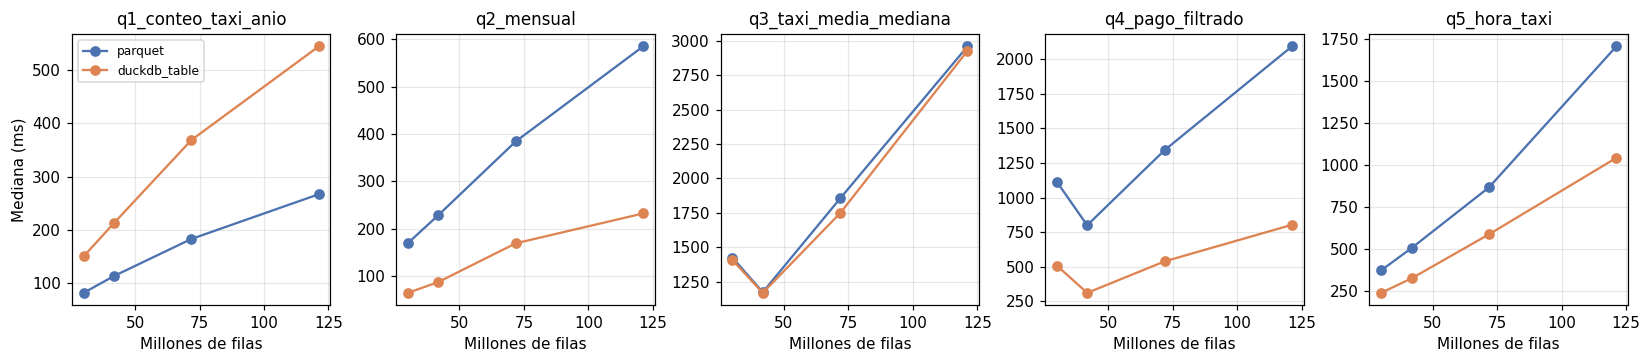

Escritos: /workspace/sql/eda.sql /workspace/sql/benchmark.sql


0

In [38]:
# Benchmark en el escenario completo, misma metodología (la tabla ahora contiene los tres años)
SCOPE_3 = {"+".join(map(str, YEARS_3)): YEARS_3}
bench_runs_3, bench_summary_3 = bench.correr(repeats=5, scopes=SCOPE_3)
bench_summary_all = pd.concat([bench_summary, bench_summary_3], ignore_index=True)
bench_summary_all.to_csv(lc.DOCS_DIR / "benchmark_results.csv", index=False)
display(bench_summary_3)

# Mediana vs cantidad de filas del escenario
filas_scope = {"2024": val_3.query("source_year == 2024").record_count.sum(),
               "2026": val_3.query("source_year == 2026").record_count.sum(),
               "2024+2026": val_3.query("source_year in [2024, 2026]").record_count.sum(),
               list(SCOPE_3)[0]: val_3.record_count.sum()}
esc = bench_summary_all.assign(rows_m=lambda d: d.data_scope.map(filas_scope) / 1e6).sort_values("rows_m")
fig, axs = plt.subplots(1, 5, figsize=(15, 3.4), sharex=True)
for ax, (qn, d) in zip(axs, esc.groupby("query_name")):
    for src, color in (("parquet", "#4c72b0"), ("duckdb_table", "#dd8452")):
        dd = d[d.source == src]
        ax.plot(dd.rows_m, dd.median_ms, "o-", color=color, label=src)
    ax.set(title=qn, xlabel="Millones de filas"); ax.grid(alpha=.3)
axs[0].set_ylabel("Mediana (ms)"); axs[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

gsql.main()      # sql/eda.sql y sql/benchmark.sql desde las mismas definiciones de Python

**Interpretación:** sin cambiar ningún código, las 21 consultas del EDA corrieron sobre los tres años directo desde Parquet (209 s para 121 M filas) y el EDA de 2026 es idéntico al de la sección 10. En el escenario de tres años, el benchmark repite el patrón: Parquet gana en q1 (267 vs 545 ms), empate en q3 (2,958 vs 2,926 ms) y la tabla gana en q2 (2.5×), q4 (2.6×) y q5 (1.6×). Las curvas de mediana frente a millones de filas son casi lineales en las dos fuentes. `sql/eda.sql` y `sql/benchmark.sql` se regeneraron con los tres años.

## Indicadores y preguntas de análisis

Preguntas que guían los indicadores (sobre 2024, 2025 y 2026):

1. ¿Cómo evoluciona el volumen de viajes por mes, año y tipo de taxi? → **Indicador A**
2. ¿Cuál es la distancia promedio y mediana por año y tipo? → **Indicador B**
3. ¿Cuál es la duración mediana de los viajes por año y tipo? → **Indicador C**
4. ¿Cuál es el monto total promedio por viaje? → **Indicador D**
5. ¿Cómo se distribuyen los métodos de pago? → **Indicador E**
6. ¿Qué porcentaje de los viajes válidos registra propina y cuál es el porcentaje de propina típico? → **Indicador F**
7. ¿En qué horas del día se concentra la demanda? → **Indicador G**
8. ¿Qué días de la semana concentran mayor volumen? → **Indicador G**
9. ¿Qué ubicaciones de pickup concentran mayor número de viajes? → consulta `ind_top_pickup` (sección de evolución)
10. ¿Qué proporción de registros presenta alguna bandera de calidad? → **Indicador H**
11. ¿Cómo evoluciona la relación distancia–tarifa? → consulta `ind_distancia_tarifa` (sección de evolución)
12. ¿Qué diferencias entre yellow y green se mantienen o cambian a través del tiempo? → todos los indicadores por tipo y año

Todas las consultas están en `sql/indicators.sql` (bloques `-- name:`), se leen desde ahí y se ejecutan sobre
`lab8.duckdb` en **solo lectura**. En esta sección se usan **todos los datos disponibles**: 2024 y 2025 completos
y 2026 hasta agosto; la comparación con meses equivalentes se hace en la sección de evolución.

In [39]:
con_ind = lc.nueva_conexion(lc.DB_PATH, read_only=True)
IND = lc.cargar_sql(lc.SQL_DIR / "indicators.sql")
print("Consultas en sql/indicators.sql:", list(IND))


def indicador(nombre, filtros="", ver_sql=True):
    """Ejecuta un bloque de sql/indicators.sql; `filtros` reemplaza el marcador /*filtros*/."""
    sql = IND[nombre].replace("/*filtros*/", filtros)
    if ver_sql:
        print(sql)
    return con_ind.execute(sql).fetchdf()


def barras_anio_taxi(ax, df, col, titulo, ylabel, fmt="{:.1f}"):
    """Barras agrupadas: año en el eje x, una barra por tipo de taxi."""
    anios = sorted(df.source_year.unique())
    x = np.arange(len(anios))
    for i, taxi in enumerate(lc.TAXIS):
        d = df[df.taxi_type == taxi].set_index("source_year").reindex(anios)
        b = ax.bar(x + (i - .5) * .38, d[col], width=.38, color=lc.COLOR[taxi], label=taxi)
        ax.bar_label(b, labels=[fmt.format(v) for v in d[col]], fontsize=7, padding=1)
    ax.set_xticks(x, [f"{a}*" if a == max(anios) else str(a) for a in anios])
    ax.set(title=titulo, ylabel=ylabel); ax.grid(axis="y", alpha=.3)

Consultas en sql/indicators.sql: ['cobertura_meses', 'ind_a_volumen_mensual', 'ind_b_distancia', 'ind_c_duracion', 'ind_d_monto_total', 'ind_e_pagos', 'ind_f_propinas', 'ind_g_demanda_hora_dia', 'ind_h_calidad', 'ind_top_pickup', 'ind_distancia_tarifa', 'evo_volumen_ytd']


### Indicador A — Volumen mensual de viajes

**Pregunta:** ¿Cómo cambia el número de viajes a través del tiempo?

**Justificación:** Es la medida base de demanda y permite ver estacionalidad, tendencia y huecos de cobertura.

**Fuente:** vista `trips_enriched` (todos los registros publicados) en `lab8.duckdb`.

**Definición:** `COUNT(*)` por `source_year`, `source_month` y `taxi_type`; sin filtros de calidad.

**Consulta SQL:** en la siguiente celda (bloque `ind_a_*` de `sql/indicators.sql`).

**Visualización:** líneas temporales, un panel por tipo porque yellow tiene unas 50–100 veces más viajes que green.

-- Indicador A. Registros por mes de archivo fuente y tipo (todos los registros publicados).
SELECT source_year, source_month, taxi_type,
       make_date(source_year, source_month, 1) AS month_start,
       COUNT(*) AS trip_count
FROM trips_enriched
WHERE TRUE 
GROUP BY ALL
ORDER BY ALL


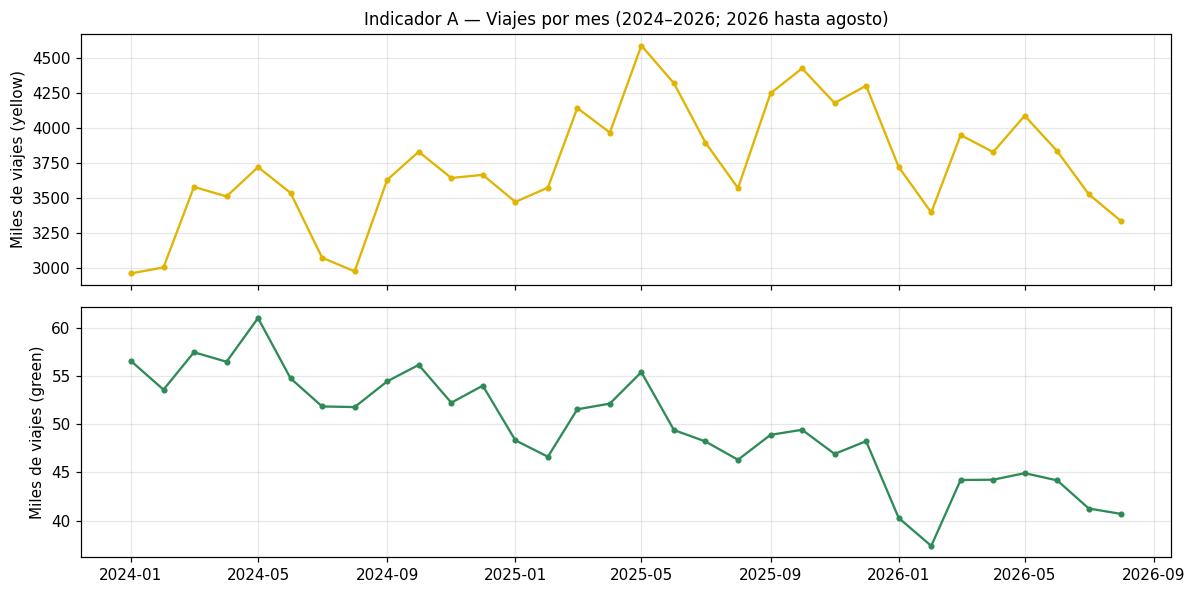

taxi_type       green                       yellow                      
source_year      2024     2025     2026       2024       2025       2026
source_month                                                            
1             56551.0  48326.0  40272.0  2964624.0  3475226.0  3724889.0
2             53577.0  46621.0  37373.0  3007526.0  3577543.0  3399866.0
3             57457.0  51539.0  44208.0  3582628.0  4145257.0  3952451.0
4             56471.0  52132.0  44238.0  3514289.0  3970553.0  3831240.0
5             61003.0  55399.0  44921.0  3723833.0  4591845.0  4090836.0
6             54748.0  49390.0  44163.0  3539193.0  4322960.0  3837248.0
7             51837.0  48205.0  41252.0  3076903.0  3898963.0  3530109.0
8             51771.0  46306.0  40687.0  2979183.0  3574091.0  3336716.0
9             54440.0  48893.0      NaN  3633030.0  4251015.0        NaN
10            56147.0  49416.0      NaN  3833771.0  4428699.0        NaN
11            52222.0  46912.0      NaN  3646369.0  4181444.0        NaN
12            53994.0  48236.0      NaN  3668371.0  4305006.0        NaN

In [40]:
ind_a = indicador("ind_a_volumen_mensual")
fig, axs = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for ax, taxi in zip(axs, lc.TAXIS):
    d = ind_a[ind_a.taxi_type == taxi]
    ax.plot(d.month_start, d.trip_count / 1e3, "o-", ms=3, color=lc.COLOR[taxi])
    ax.set(ylabel=f"Miles de viajes ({taxi})"); ax.grid(alpha=.3)
axs[0].set_title("Indicador A — Viajes por mes (2024–2026; 2026 hasta agosto)")
plt.tight_layout(); plt.show()
display(ind_a.pivot_table(index="source_month", columns=["taxi_type", "source_year"], values="trip_count"))

**Interpretación:** yellow tiene un patrón estacional estable, con mínimos en enero–febrero y julio–agosto y máximos en mayo y octubre (4.59 millones en mayo de 2025). Green baja de forma sostenida: cada mes de 2025 queda por debajo del mismo mes de 2024 y cada mes de 2026, por debajo de 2025 (enero: 56,551 → 48,326 → 40,272). 2026 llega hasta agosto, por lo que su total anual no es comparable.

### Indicador B — Distancia típica

**Pregunta:** ¿Cuál es la distancia promedio y mediana por año y tipo?

**Justificación:** Resume el tipo de viaje que atiende cada servicio; la diferencia entre media y mediana muestra la cola larga.

**Fuente:** vista `trips_valid`.

**Definición:** `AVG`, `median` y `quantile_cont(0.95)` de `trip_distance` (millas) por año y tipo.

**Consulta SQL:** en la siguiente celda (bloque `ind_b_*` de `sql/indicators.sql`).

**Visualización:** barras agrupadas por año y tipo; la mediana es la métrica principal y la media se muestra al lado.

-- Indicador B. Distancia típica (millas) de viajes válidos.
SELECT source_year, taxi_type,
       COUNT(*) AS n_valid,
       AVG(trip_distance) AS avg_distance_mi,
       median(trip_distance) AS median_distance_mi,
       quantile_cont(trip_distance, 0.95) AS p95_distance_mi
FROM trips_valid
WHERE TRUE 
GROUP BY ALL
ORDER BY ALL


,source_year,taxi_type,n_valid,avg_distance_mi,median_distance_mi,p95_distance_mi
0,2024,green,655485,2.80,1.88,8.46
1,2024,yellow,40410134,3.36,1.76,14.22
2,2025,green,584420,3.07,1.99,9.74
3,2025,yellow,45310913,3.40,1.83,12.94
4,2026,green,334831,3.25,2.08,10.51
5,2026,yellow,29162994,3.41,1.87,12.28


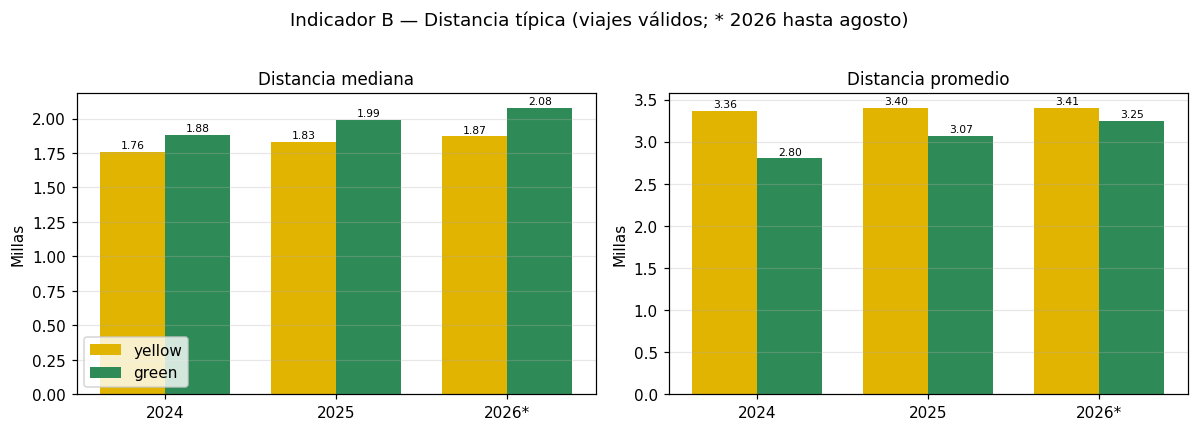

In [41]:
ind_b = indicador("ind_b_distancia")
display(ind_b.round(2))
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
barras_anio_taxi(axs[0], ind_b, "median_distance_mi", "Distancia mediana", "Millas", "{:.2f}")
barras_anio_taxi(axs[1], ind_b, "avg_distance_mi", "Distancia promedio", "Millas", "{:.2f}")
axs[0].legend(); fig.suptitle("Indicador B — Distancia típica (viajes válidos; * 2026 hasta agosto)", y=1.02)
plt.tight_layout(); plt.show()

**Interpretación:** la distancia mediana aumenta poco a poco en ambos tipos: yellow 1.76 → 1.83 → 1.87 mi y green 1.88 → 1.99 → 2.08 mi (2024, 2025, 2026 con datos disponibles). La media de yellow (~3.4 mi) casi duplica la mediana por la cola de viajes largos; su p95 baja de 14.2 a 12.3 mi. Green tiene medianas más altas pero medias más bajas que yellow.

### Indicador C — Duración típica

**Pregunta:** ¿Cuál es la duración mediana de los viajes por año y tipo?

**Justificación:** La duración refleja congestión y longitud del viaje; la mediana es poco sensible a duraciones extremas.

**Fuente:** vista `trips_valid`.

**Definición:** `median(trip_minutes)` y percentiles 25/75 por mes y, con `GROUPING SETS`, por año completo.

**Consulta SQL:** en la siguiente celda (bloque `ind_c_*` de `sql/indicators.sql`).

**Visualización:** línea mensual por tipo para ver estacionalidad y cambios de nivel.

-- Indicador C. Duración mediana (minutos) de viajes válidos. GROUPING SETS devuelve en una sola
-- consulta el nivel mensual y el anual (filas con source_month NULL = año completo disponible).
SELECT source_year, source_month, taxi_type,
       make_date(source_year, source_month, 1) AS month_start,
       COUNT(*) AS n_valid,
       median(trip_minutes) AS median_minutes,
       quantile_cont(trip_minutes, 0.25) AS p25_minutes,
       quantile_cont(trip_minutes, 0.75) AS p75_minutes
FROM trips_valid
WHERE TRUE 
GROUP BY GROUPING SETS ((source_year, source_month, taxi_type), (source_year, taxi_type))
ORDER BY source_year, taxi_type, source_month NULLS FIRST


,source_year,taxi_type,n_valid,median_minutes,p25_minutes,p75_minutes
0,2024,green,655485,11.98,7.67,18.30
13,2024,yellow,40410134,13.03,7.88,21.15
26,2025,green,584420,12.60,8.10,19.33
39,2025,yellow,45310913,13.52,8.23,21.52
52,2026,green,334831,13.13,8.40,20.50
61,2026,yellow,29162994,14.12,8.57,22.27


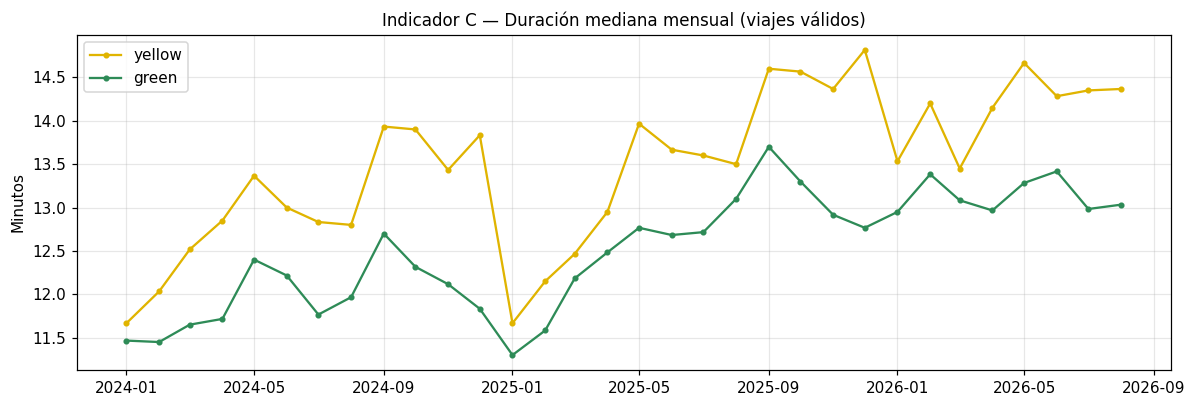

In [42]:
ind_c = indicador("ind_c_duracion")
anual_c = ind_c[ind_c.source_month.isna()].drop(columns=["source_month", "month_start"])
display(anual_c.round(2))
mens_c = ind_c[ind_c.source_month.notna()]
fig, ax = plt.subplots(figsize=(11, 3.8))
for taxi in lc.TAXIS:
    d = mens_c[mens_c.taxi_type == taxi]
    ax.plot(d.month_start, d.median_minutes, "o-", ms=3, color=lc.COLOR[taxi], label=taxi)
ax.set(title="Indicador C — Duración mediana mensual (viajes válidos)", ylabel="Minutos"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretación:** la duración mediana crece en ambos tipos: yellow 13.0 → 13.5 → 14.1 min y green 12.0 → 12.6 → 13.1 min. La línea mensual muestra caídas en enero y en verano y máximos en primavera y otoño, con el nivel de 2026 por encima de los años anteriores. Como la distancia mediana crece menos que la duración, los viajes también son algo más lentos (asociación descriptiva).

### Indicador D — Monto total por viaje

**Pregunta:** ¿Cuál es el monto total promedio por viaje?

**Justificación:** Mide el costo pagado por el pasajero (sin propinas en efectivo) y su cambio entre años.

**Fuente:** vista `trips_valid` (excluye totales y tarifas negativas, fechas inválidas, velocidad > 100 mph y duración > 24 h).

**Definición:** `AVG` y `median` de `total_amount` (USD) por año y tipo; se incluye `AVG(fare_amount)` como referencia.

**Consulta SQL:** en la siguiente celda (bloque `ind_d_*` de `sql/indicators.sql`).

**Visualización:** barras agrupadas por año y tipo.

-- Indicador D. Monto total por viaje (USD) de viajes válidos (total_amount >= 0 por la regla de validez).
SELECT source_year, taxi_type,
       COUNT(*) AS n_valid,
       AVG(total_amount) AS avg_total_usd,
       median(total_amount) AS median_total_usd,
       AVG(fare_amount) AS avg_fare_usd
FROM trips_valid
WHERE TRUE 
GROUP BY ALL
ORDER BY ALL


,source_year,taxi_type,n_valid,avg_total_usd,median_total_usd,avg_fare_usd
0,2024,green,655485,24.36,19.32,18.42
1,2024,yellow,40410134,28.75,21.22,19.96
2,2025,green,584420,25.32,20.10,18.21
3,2025,yellow,45310913,28.98,22.05,20.22
4,2026,green,334831,25.57,20.50,17.05
5,2026,yellow,29162994,30.44,23.75,21.56


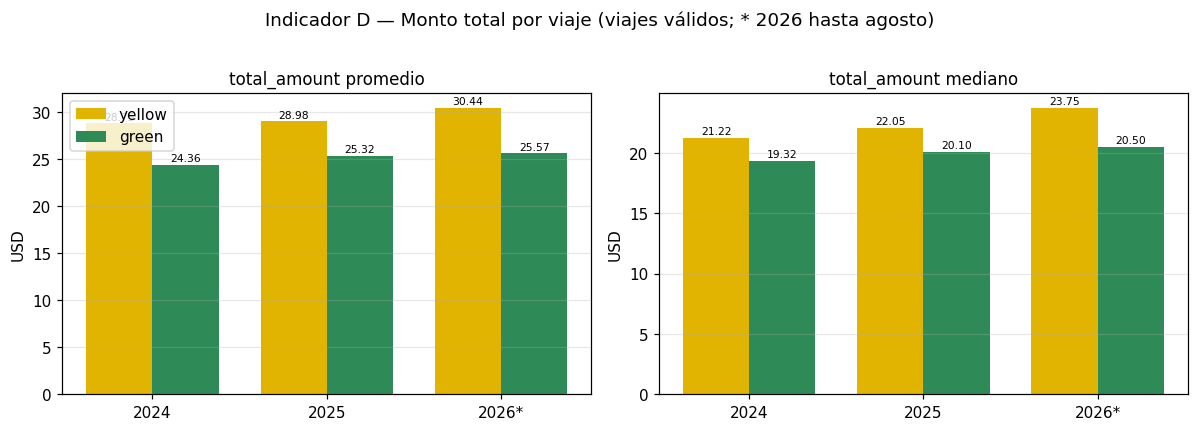

In [43]:
ind_d = indicador("ind_d_monto_total")
display(ind_d.round(2))
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
barras_anio_taxi(axs[0], ind_d, "avg_total_usd", "total_amount promedio", "USD", "{:.2f}")
barras_anio_taxi(axs[1], ind_d, "median_total_usd", "total_amount mediano", "USD", "{:.2f}")
axs[0].legend(); fig.suptitle("Indicador D — Monto total por viaje (viajes válidos; * 2026 hasta agosto)", y=1.02)
plt.tight_layout(); plt.show()

**Interpretación:** el total promedio de yellow pasa de 28.75 USD (2024) a 28.98 (2025) y 30.44 (2026), y la mediana, de 21.22 a 23.75 USD; en green, de 24.36 a 25.57 USD de promedio. La tarifa promedio de yellow sube de 19.96 a 21.56 USD, pero la de green baja de 18.42 a 17.05, así que el aumento del total en green viene de otros cargos y no de la tarifa base.

### Indicador E — Métodos de pago

**Pregunta:** ¿Cómo se distribuyen los métodos de pago?

**Justificación:** La forma de pago condiciona qué propinas se registran y describe hábitos de pago por servicio.

**Fuente:** vista `trips_enriched` (todos los registros).

**Definición:** cantidad y % de viajes por `payment_type` dentro de cada tipo y año; etiquetas del diccionario oficial de la TLC (18-mar-2025).

**Consulta SQL:** en la siguiente celda (bloque `ind_e_*` de `sql/indicators.sql`).

**Visualización:** barras apiladas al 100 % por tipo y año.

-- Indicador E. Métodos de pago: cantidad y % dentro de cada tipo/año (todos los registros).
SELECT source_year, taxi_type, payment_type,
       CASE payment_type
            WHEN 0 THEN '0 Flex Fare' WHEN 1 THEN '1 Tarjeta' WHEN 2 THEN '2 Efectivo'
            WHEN 3 THEN '3 Sin cargo' WHEN 4 THEN '4 Disputa' WHEN 5 THEN '5 Desconocido'
            WHEN 6 THEN '6 Anulado' ELSE 'NULL (sin código)' END AS payment_label,
       COUNT(*) AS trip_count,
       100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY source_year, taxi_type) AS pct
FROM trips_enriched
WHERE TRUE 
GROUP BY source_year, taxi_type, payment_type
ORDER BY source_year, taxi_type, payment_type NULLS LAST


payment_label          0 Flex Fare  1 Tarjeta  2 Efectivo  3 Sin cargo  4 Disputa  5 Desconocido  NULL (sin código)
taxi_type source_year                                                                                              
green     2024                0.00      68.87       26.51         0.70       0.24            0.0               3.68
          2025                0.00      68.76       21.95         0.64       0.21            0.0               8.43
          2026                0.00      65.25       19.55         0.50       0.22            0.0              14.47
yellow    2024                9.94      73.97       13.46         0.71       1.93            0.0               0.00
          2025               23.83      63.74        9.55         0.63       2.25            0.0               0.00
          2026               25.98      63.77        9.12         0.33       0.81            0.0               0.00

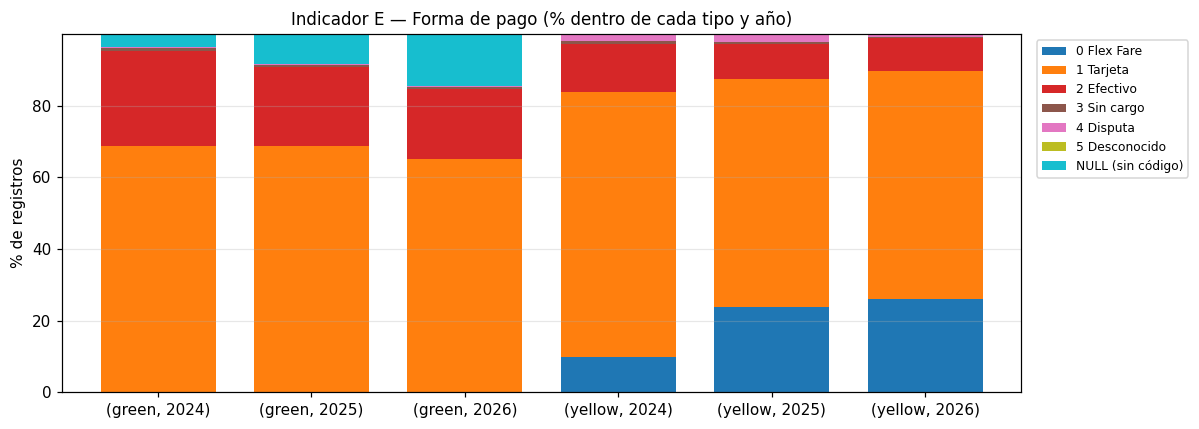

In [44]:
ind_e = indicador("ind_e_pagos")
piv_e = ind_e.pivot_table(index=["taxi_type", "source_year"], columns="payment_label", values="pct", fill_value=0)
display(piv_e.round(2))
ax = piv_e.plot.bar(stacked=True, figsize=(11, 4), colormap="tab10", rot=0, width=.75)
ax.set(title="Indicador E — Forma de pago (% dentro de cada tipo y año)", xlabel="", ylabel="% de registros")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

**Interpretación:** la composición de pagos cambia mucho entre años. En yellow, el código 0 (Flex Fare) pasa de 9.9 % (2024) a 23.8 % (2025) y 26.0 % (2026), mientras la tarjeta baja de 74.0 % a 63.8 % y el efectivo de 13.5 % a 9.1 %. En green, los registros sin código (`NULL`) crecen de 3.7 % a 8.4 % y 14.5 % y el efectivo baja de 26.5 % a 19.6 %. Parte de la caída de tarjeta y efectivo coincide con el crecimiento de esos bloques sin forma de pago convencional.

### Indicador F — Propinas

**Pregunta:** ¿Qué porcentaje de los viajes válidos registra propina y cuál es el porcentaje de propina típico?

**Justificación:** Solo con tarjeta la propina queda registrada, así que mezclar efectivo subestimaría la propina.

**Fuente:** vista `trips_valid`, solo `payment_type = 1` y `fare_amount > 0`.

**Definición:** `100 * AVG(tip_amount > 0)` y `median(tip_percentage)`, con `tip_percentage = 100 * tip_amount / fare_amount`.

**Consulta SQL:** en la siguiente celda (bloque `ind_f_*` de `sql/indicators.sql`).

**Visualización:** dos paneles de barras agrupadas por año y tipo.

-- Indicador F. Propinas: solo viajes válidos pagados con tarjeta (la TLC no registra propinas en efectivo)
-- y con fare_amount > 0. tip_percentage = 100 * tip_amount / fare_amount.
SELECT source_year, taxi_type,
       COUNT(*) AS n_card_trips,
       100.0 * AVG((tip_amount > 0)::INTEGER) AS pct_with_tip,
       median(tip_percentage) AS median_tip_pct,
       AVG(tip_percentage) AS mean_tip_pct,
       median(tip_amount) AS median_tip_usd
FROM trips_valid
WHERE payment_type = 1 AND fare_amount > 0 
GROUP BY ALL
ORDER BY ALL


,source_year,taxi_type,n_card_trips,pct_with_tip,median_tip_pct,mean_tip_pct,median_tip_usd
0,2024,green,453236,88.08,23.23,22.31,3.00
1,2024,yellow,30442046,94.17,25.75,26.19,3.25
2,2025,green,405181,89.33,23.24,22.78,3.00
3,2025,yellow,30584631,92.59,26.38,26.50,3.30
4,2026,green,219143,90.54,23.49,25.60,3.08
5,2026,yellow,18614449,91.01,26.38,25.39,3.29


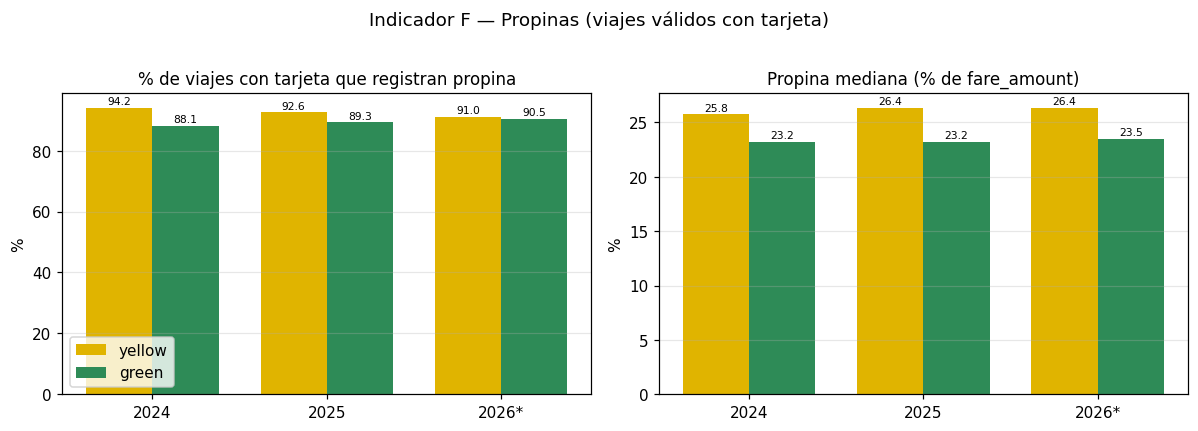

In [45]:
ind_f = indicador("ind_f_propinas")
display(ind_f.round(2))
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
barras_anio_taxi(axs[0], ind_f, "pct_with_tip", "% de viajes con tarjeta que registran propina", "%")
barras_anio_taxi(axs[1], ind_f, "median_tip_pct", "Propina mediana (% de fare_amount)", "%")
axs[0].legend(loc="lower left"); fig.suptitle("Indicador F — Propinas (viajes válidos con tarjeta)", y=1.02)
plt.tight_layout(); plt.show()

**Interpretación:** entre viajes válidos con tarjeta, el porcentaje con propina baja en yellow (94.2 % → 92.6 % → 91.0 %) y sube en green (88.1 % → 89.3 % → 90.5 %). La propina mediana es estable: ~26 % de la tarifa en yellow (25.8 → 26.4) y ~23 % en green. La propina típica en dólares es de unos 3 USD en ambos tipos.

### Indicador G — Patrón de demanda por hora y día

**Pregunta:** ¿En qué horas y días de la semana se concentra la demanda?

**Justificación:** Identifica picos operativos y diferencias de patrón entre servicios.

**Fuente:** vista `trips_enriched`, sin pickups nulos ni fuera del mes del archivo.

**Definición:** `COUNT(*)` por `pickup_weekday` (1 = lunes) y `pickup_hour`, y % sobre el total del tipo.

**Consulta SQL:** en la siguiente celda (bloque `ind_g_*` de `sql/indicators.sql`).

**Visualización:** heatmap día × hora por tipo (porcentaje, para comparar tipos con volúmenes distintos).

-- Indicador G. Viajes por día de la semana (1 = lunes ... 7 = domingo) y hora de recogida.
-- Se excluyen pickups nulos o fuera del mes del archivo fuente.
SELECT taxi_type, pickup_weekday, pickup_hour,
       COUNT(*) AS trip_count,
       100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY taxi_type) AS pct_of_taxi
FROM trips_enriched
WHERE pickup_datetime IS NOT NULL AND NOT is_pickup_outside_source_month 
GROUP BY taxi_type, pickup_weekday, pickup_hour
ORDER BY ALL


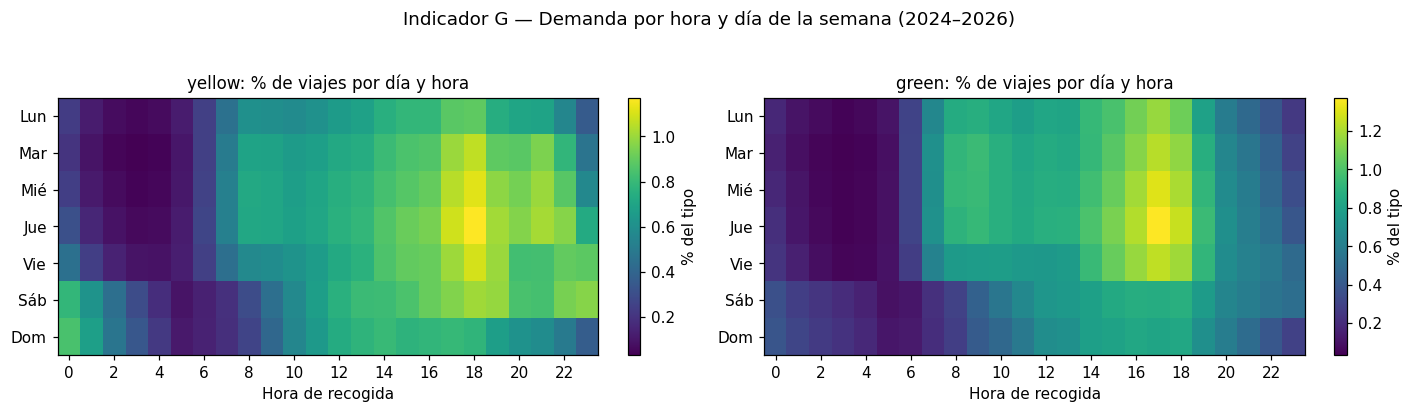

taxi_type,green,yellow
pickup_weekday,,
Lun,14.28,12.22
Mar,15.03,13.99
Mié,15.61,14.84
Jue,16.02,15.59
Vie,15.05,14.94
Sáb,12.46,15.39
Dom,11.55,13.03


pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
taxi_type,,,,,,,,,,,,,,,,,,,,,,,,
green,1.71,1.16,0.83,0.65,0.61,0.68,1.75,3.81,4.93,5.34,5.29,5.28,5.61,5.63,6.34,6.89,7.49,7.99,7.58,5.92,4.55,3.98,3.38,2.60
yellow,3.07,2.02,1.33,0.91,0.71,0.77,1.55,2.84,3.86,4.14,4.33,4.67,5.09,5.32,5.72,5.93,6.08,6.77,7.12,6.28,5.76,5.91,5.51,4.34


In [46]:
ind_g = indicador("ind_g_demanda_hora_dia")
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, taxi in zip(axs, lc.TAXIS):
    m = ind_g[ind_g.taxi_type == taxi].pivot(index="pickup_weekday", columns="pickup_hour", values="pct_of_taxi")
    im = ax.imshow(m, aspect="auto", cmap="viridis")
    ax.set_yticks(range(7), [lc.DIAS[d] for d in m.index]); ax.set_xticks(range(0, 24, 2))
    ax.set(title=f"{taxi}: % de viajes por día y hora", xlabel="Hora de recogida")
    fig.colorbar(im, ax=ax, fraction=.03, label="% del tipo")
fig.suptitle("Indicador G — Demanda por hora y día de la semana (2024–2026)", y=1.03)
plt.tight_layout(); plt.show()
tot_g = ind_g.groupby(["taxi_type", "pickup_weekday"]).pct_of_taxi.sum().unstack(0).rename(index=lc.DIAS)
display(tot_g.round(2))
display(ind_g.groupby(["taxi_type", "pickup_hour"]).pct_of_taxi.sum().unstack(0).round(2).T)

**Interpretación:** en los tres años, la demanda se concentra por la tarde: el pico es a las 17 h en green (7.99 %) y a las 18 h en yellow (7.12 %). Yellow conserva actividad nocturna (5.5–5.9 % por hora entre 20 y 22 h) y su volumen semanal es alto también el sábado (15.4 %), mientras que green cae en fin de semana (12.5 % sábado, 11.6 % domingo) y tiene un perfil más laboral, con la mañana de 7 a 9 h más marcada.

### Indicador H — Calidad de datos

**Pregunta:** ¿Qué proporción de registros presenta alguna bandera de calidad?

**Justificación:** Cuantifica cuánta información se excluye de las métricas válidas y si la calidad cambia en el tiempo.

**Fuente:** vista `trips_enriched` (todos los registros).

**Definición:** % de filas con al menos una bandera: datetime inválido o duración no positiva, distancia negativa, tarifa negativa, total negativo, velocidad > 100 mph o duración > 24 h; además el % de cada bandera.

**Consulta SQL:** en la siguiente celda (bloque `ind_h_*` de `sql/indicators.sql`).

**Visualización:** barras agrupadas por año y tipo.

-- Indicador H. % de registros con al menos una bandera problemática (todos los registros).
SELECT source_year, taxi_type,
       COUNT(*) AS n_rows,
       COUNT(*) FILTER (WHERE is_invalid_datetime OR is_negative_distance OR is_negative_fare
                           OR is_negative_total OR is_extreme_speed OR is_extreme_duration) AS n_flagged,
       100.0 * COUNT(*) FILTER (WHERE is_invalid_datetime OR is_negative_distance OR is_negative_fare
                                   OR is_negative_total OR is_extreme_speed OR is_extreme_duration)
             / COUNT(*) AS pct_flagged,
       100.0 * COUNT(*) FILTER (WHERE pickup_datetime IS NULL OR dropoff_datetime IS NULL) / COUNT(*) AS pct_null_datetime,
       100.0 * COUNT(*) FILTER (WHERE trip_minutes <= 0) / COUNT(*) AS pct_non_positive_duration,
       100.0 * COUNT(*) FILTER (WHERE is_negative_distance) / COUNT(*) AS pct_negative_distance,
       100.0 * COUNT(*) FILTER (WHERE is_negative_fare) / COUNT(*) AS pct_negative_fare,


,source_year,taxi_type,n_rows,n_flagged,pct_flagged,pct_null_datetime,pct_non_positive_duration,pct_negative_distance,pct_negative_fare,pct_negative_total,pct_extreme_speed,pct_extreme_duration
0,2024,green,660218,4733,0.717,0.0,0.100,0.0,0.325,0.329,0.287,0.000
1,2024,yellow,41169720,759586,1.845,0.0,0.033,0.0,1.776,1.480,0.030,0.001
2,2025,green,591375,6955,1.176,0.0,0.323,0.0,0.294,0.300,0.554,0.000
3,2025,yellow,48722602,3411689,7.002,0.0,1.121,0.0,5.847,1.998,0.025,0.001
4,2026,green,337114,2283,0.677,0.0,0.069,0.0,0.296,0.303,0.303,0.001
5,2026,yellow,29703355,540361,1.819,0.0,1.251,0.0,0.530,0.545,0.022,0.001


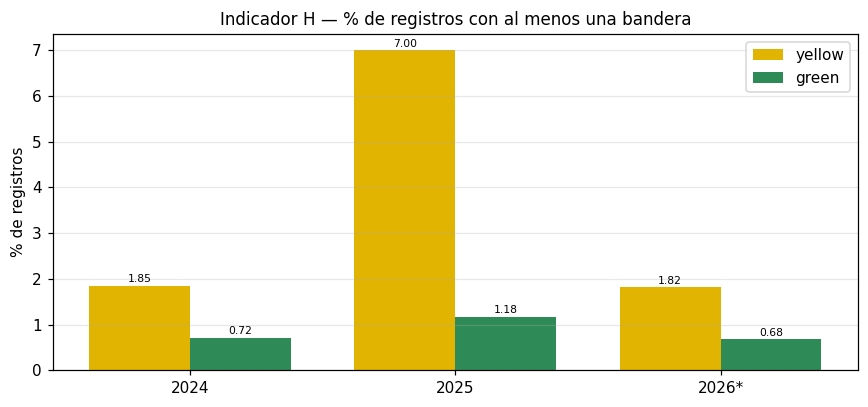

In [47]:
ind_h = indicador("ind_h_calidad")
display(ind_h.round(3))
fig, ax = plt.subplots(figsize=(8, 3.8))
barras_anio_taxi(ax, ind_h, "pct_flagged", "Indicador H — % de registros con al menos una bandera", "% de registros", "{:.2f}")
ax.legend(); plt.tight_layout(); plt.show()

**Interpretación:** la calidad es estable en 2024 y 2026 (~1.8 % de registros yellow y ~0.7 % green con alguna bandera), pero **yellow 2025 sube a 7.0 %**. La causa observada en los datos es la tarifa negativa (5.85 % de los registros yellow de 2025, frente a 1.78 % en 2024 y 0.53 % en 2026), concentrada en registros Flex Fare con total positivo (una consulta auxiliar dio 2.05 millones de casos con tarifa media −4.33 USD y total medio +3.67 USD), y que baja abruptamente en diciembre de 2025. También crece la duración no positiva en yellow (0.03 % en 2024 → 1.25 % en 2026). Estas banderas excluyen esos registros de las métricas válidas.

## Evolución de indicadores 2024–2026

### Cobertura de meses

2026 está incompleto, así que no se comparan totales anuales directamente. Se calcula la cobertura por tipo
y año y se determina **automáticamente** el último mes comparable.

**Criterio:** último mes común global, es decir, el menor `max_month` entre todas las combinaciones tipo × año,
verificando que cada combinación empiece en enero y no tenga huecos. Se eligió el criterio global porque yellow y
green tienen la misma cobertura; así la comparación usa los mismos meses para ambos tipos.

In [48]:
cob = indicador("cobertura_meses")
display(cob)
assert ((cob.min_month == 1) & (cob.months_available == cob.max_month)).all(), "hay huecos de cobertura"
MES_COMUN = int(cob.max_month.min())
YTD = f"AND source_month <= {MES_COMUN}"
print(f"Último mes comparable: {MES_COMUN} -> comparación YTD enero–{MES_COMUN} de {YEARS_3}")

-- Meses disponibles por tipo y año (base para la comparación YTD).
SELECT taxi_type, source_year,
       MIN(source_month) AS min_month,
       MAX(source_month) AS max_month,
       COUNT(DISTINCT source_month) AS months_available
FROM trips
GROUP BY ALL
ORDER BY ALL


,taxi_type,source_year,min_month,max_month,months_available
0,green,2024,1,12,12
1,green,2025,1,12,12
2,green,2026,1,8,8
3,yellow,2024,1,12,12
4,yellow,2025,1,12,12
5,yellow,2026,1,8,8


Último mes comparable: 8 -> comparación YTD enero–8 de [2024, 2025, 2026]


### Volumen

Dos perspectivas: **datos disponibles completos** (2026 parcial, solo como referencia) y **YTD comparable**
(enero hasta el último mes común en los tres años).

,taxi_type,source_year,trips_disponibles,trips_ytd,var_ytd_vs_anio_previo_%
0,green,2024,660218,443415,NaN
1,green,2025,591375,397918,-10.26
2,green,2026,337114,337114,-15.28
3,yellow,2024,41169720,26388179,NaN
4,yellow,2025,48722602,31556438,19.59
5,yellow,2026,29703355,29703355,-5.87


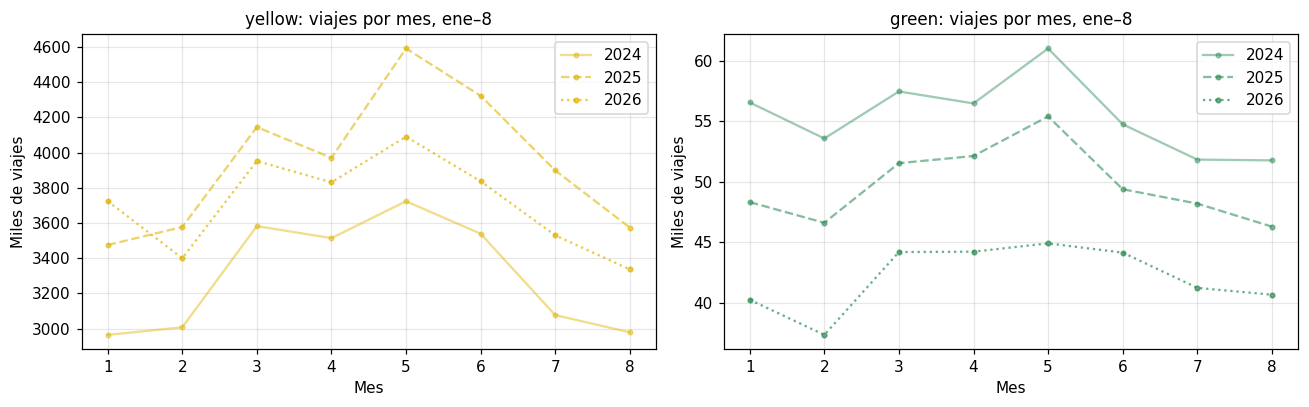

In [49]:
vol_full = ind_a.groupby(["taxi_type", "source_year"]).trip_count.sum().rename("trips_disponibles")
ind_a_ytd = indicador("ind_a_volumen_mensual", YTD, ver_sql=False)
vol_ytd = ind_a_ytd.groupby(["taxi_type", "source_year"]).trip_count.sum().rename("trips_ytd")
vol = pd.concat([vol_full, vol_ytd], axis=1).reset_index()
vol["var_ytd_vs_anio_previo_%"] = (vol.groupby("taxi_type").trips_ytd.pct_change() * 100).round(2)
display(vol)

# Misma cifra con la consulta autocontenida que usa el tablero (calcula el mes común en SQL)
evo_sql = indicador("evo_volumen_ytd", ver_sql=False)
chk_ytd = evo_sql.merge(vol, on=["taxi_type", "source_year"], suffixes=("_sql", ""))
assert len(chk_ytd) == len(vol) and (chk_ytd.trips_ytd_sql == chk_ytd.trips_ytd).all()
assert int(evo_sql.mes_comun.iloc[0]) == MES_COMUN

fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, taxi in zip(axs, lc.TAXIS):
    d = ind_a_ytd[ind_a_ytd.taxi_type == taxi]
    for y, ls in zip(YEARS_3, ("-", "--", ":")):
        dd = d[d.source_year == y]
        ax.plot(dd.source_month, dd.trip_count / 1e3, ls, marker="o", ms=3, color=lc.COLOR[taxi], alpha=.45 + .25 * (y - YEARS_3[0]) / 2, label=str(y))
    ax.set(title=f"{taxi}: viajes por mes, ene–{MES_COMUN}", xlabel="Mes", ylabel="Miles de viajes"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretación:** con los mismos meses (enero–agosto), yellow sube 19.6 % de 2024 a 2025 (26.4 → 31.6 millones) y baja 5.9 % en 2026 (29.7 millones), mientras que green cae en ambos años: −10.3 % en 2025 y −15.3 % en 2026 (443 mil → 398 mil → 337 mil). Comparar el total disponible de 2026 (29.7 M) con el año completo de 2025 (48.7 M) sugeriría una caída de 39 %, que es un artefacto de cobertura.

### Distancia, duración, monto, pagos, propinas y calidad (YTD comparable)

Cada indicador se recalcula con el mismo SQL de `sql/indicators.sql` agregando únicamente el filtro
`source_month <= MES_COMUN`. La tabla resume valores YTD; debajo se muestra la misma tabla con datos disponibles
completos, claramente etiquetada.

In [50]:
def resumen_evolucion(filtros):
    b = indicador("ind_b_distancia", filtros, ver_sql=False)
    c = indicador("ind_c_duracion", filtros, ver_sql=False).query("source_month.isna()", engine="python")
    d = indicador("ind_d_monto_total", filtros, ver_sql=False)
    e = indicador("ind_e_pagos", filtros, ver_sql=False)
    f = indicador("ind_f_propinas", filtros, ver_sql=False)
    h = indicador("ind_h_calidad", filtros, ver_sql=False)
    k = ["taxi_type", "source_year"]
    pago = e.pivot_table(index=k, columns="payment_type", values="pct", fill_value=0)
    out = (b[k + ["n_valid", "median_distance_mi", "avg_distance_mi"]]
           .merge(c[k + ["median_minutes"]], on=k)
           .merge(d[k + ["avg_total_usd", "median_total_usd"]], on=k)
           .merge(pago[[1.0, 2.0]].rename(columns={1.0: "pct_card", 2.0: "pct_cash"}).reset_index(), on=k)
           .merge(f[k + ["pct_with_tip", "median_tip_pct"]], on=k)
           .merge(h[k + ["pct_flagged"]], on=k))
    return out.sort_values(k).reset_index(drop=True)


evo_ytd = resumen_evolucion(YTD)
evo_full = resumen_evolucion("")
print(f"YTD comparable (enero–{MES_COMUN})")
display(evo_ytd.round(2))
print("Datos disponibles completos (2024 y 2025: 12 meses; 2026: enero–agosto)")
display(evo_full.round(2))

YTD comparable (enero–8)


,taxi_type,source_year,n_valid,median_distance_mi,avg_distance_mi,median_minutes,avg_total_usd,median_total_usd,pct_card,pct_cash,pct_with_tip,median_tip_pct,pct_flagged
0,green,2024,440151,1.86,2.78,11.83,24.01,19.20,67.93,27.18,87.98,23.23,0.74
1,green,2025,392393,1.94,2.97,12.35,24.98,19.90,69.42,22.64,88.53,23.23,1.39
2,green,2026,334831,2.08,3.25,13.13,25.57,20.50,65.25,19.55,90.54,23.49,0.68
3,yellow,2024,25937664,1.77,3.37,12.65,28.44,21.00,74.05,13.93,94.23,25.93,1.71
4,yellow,2025,29413306,1.81,3.37,13.00,28.46,21.65,63.81,9.85,93.22,26.61,6.79
5,yellow,2026,29162994,1.87,3.41,14.12,30.44,23.75,63.77,9.12,91.01,26.38,1.82


Datos disponibles completos (2024 y 2025: 12 meses; 2026: enero–agosto)


,taxi_type,source_year,n_valid,median_distance_mi,avg_distance_mi,median_minutes,avg_total_usd,median_total_usd,pct_card,pct_cash,pct_with_tip,median_tip_pct,pct_flagged
0,green,2024,655485,1.88,2.80,11.98,24.36,19.32,68.87,26.51,88.08,23.23,0.72
1,green,2025,584420,1.99,3.07,12.60,25.32,20.10,68.76,21.95,89.33,23.24,1.18
2,green,2026,334831,2.08,3.25,13.13,25.57,20.50,65.25,19.55,90.54,23.49,0.68
3,yellow,2024,40410134,1.76,3.36,13.03,28.75,21.22,73.97,13.46,94.17,25.75,1.85
4,yellow,2025,45310913,1.83,3.40,13.52,28.98,22.05,63.74,9.55,92.59,26.38,7.00
5,yellow,2026,29162994,1.87,3.41,14.12,30.44,23.75,63.77,9.12,91.01,26.38,1.82


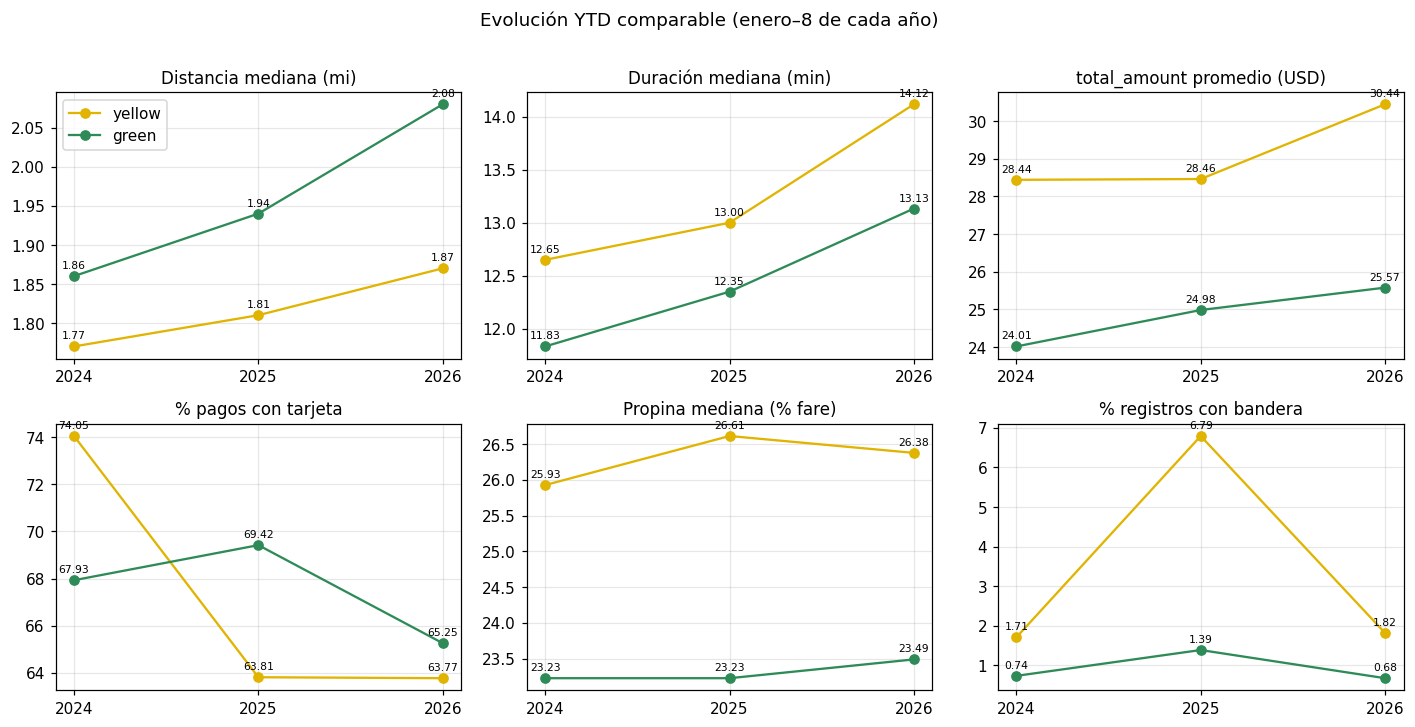

In [51]:
metricas = [("median_distance_mi", "Distancia mediana (mi)"), ("median_minutes", "Duración mediana (min)"),
            ("avg_total_usd", "total_amount promedio (USD)"), ("pct_card", "% pagos con tarjeta"),
            ("median_tip_pct", "Propina mediana (% fare)"), ("pct_flagged", "% registros con bandera")]
fig, axs = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, (col, titulo) in zip(axs.flat, metricas):
    for taxi in lc.TAXIS:
        d = evo_ytd[evo_ytd.taxi_type == taxi]
        ax.plot(d.source_year, d[col], "o-", color=lc.COLOR[taxi], label=taxi)
        for x, y in zip(d.source_year, d[col]):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=7)
    ax.set_xticks(YEARS_3); ax.set_title(titulo); ax.grid(alpha=.3)
axs[0, 0].legend()
fig.suptitle(f"Evolución YTD comparable (enero–{MES_COMUN} de cada año)", y=1.01)
plt.tight_layout(); plt.show()

**Interpretación (YTD enero–agosto):** la distancia mediana y la duración mediana crecen año a año en ambos tipos (yellow: 1.77 → 1.81 → 1.87 mi y 12.65 → 13.00 → 14.12 min; green: 1.86 → 1.94 → 2.08 mi y 11.83 → 12.35 → 13.13 min). El total promedio de yellow se mantiene en 2025 (28.44 → 28.46 USD) y sube en 2026 (30.44); el de green sube de 24.01 a 25.57 USD. El pago con tarjeta en yellow cae de 74.1 % a 63.8 % entre 2024 y 2025 y se mantiene en 2026. La propina mediana es estable y la calidad empeora solo en 2025 (yellow 6.8 %, green 1.4 %) para volver a niveles de 2024 en 2026. Las tendencias se ven igual con datos completos, lo que indica que no dependen de la estacionalidad del corte.

**Monto total y `cbd_congestion_fee`.** El diccionario de la TLC documenta `cbd_congestion_fee` como cargo por
viaje desde el 5 de enero de 2025. La columna existe en los Parquet de 2025 y 2026 pero no en 2024; la consulta
siguiente la lee directo de Parquet con `union_by_name` (en 2024 aparece como `NULL`), con el mismo filtro YTD.

In [52]:
globs = [(lc.DATA_RAW / t / str(y) / "*.parquet").as_posix() for t in lc.TAXIS for y in YEARS_3]
sql_cbd = f"""
SELECT CASE WHEN filename LIKE '%yellow_tripdata%' THEN 'yellow' ELSE 'green' END AS taxi_type,
       CAST(regexp_extract(filename, '_(\\d{{4}})-(\\d{{2}})\\.parquet$', 1) AS INTEGER) AS source_year,
       COUNT(*) AS n_rows,
       COUNT(cbd_congestion_fee) AS n_with_column,
       AVG(cbd_congestion_fee) AS avg_cbd_fee_usd,
       100.0 * AVG((cbd_congestion_fee > 0)::INTEGER) AS pct_cbd_fee_gt0,
       AVG(congestion_surcharge) AS avg_congestion_surcharge_usd
FROM read_parquet({globs}, filename = true, union_by_name = true)
WHERE CAST(regexp_extract(filename, '_(\\d{{4}})-(\\d{{2}})\\.parquet$', 2) AS INTEGER) <= {MES_COMUN}
GROUP BY ALL ORDER BY ALL"""
print(sql_cbd.replace(lc.DATA_RAW.as_posix() + "/", "data/raw/"))
cbd = con_all.execute(sql_cbd).fetchdf()
display(cbd.round(3))


SELECT CASE WHEN filename LIKE '%yellow_tripdata%' THEN 'yellow' ELSE 'green' END AS taxi_type,
       CAST(regexp_extract(filename, '_(\d{4})-(\d{2})\.parquet$', 1) AS INTEGER) AS source_year,
       COUNT(*) AS n_rows,
       COUNT(cbd_congestion_fee) AS n_with_column,
       AVG(cbd_congestion_fee) AS avg_cbd_fee_usd,
       100.0 * AVG((cbd_congestion_fee > 0)::INTEGER) AS pct_cbd_fee_gt0,
       AVG(congestion_surcharge) AS avg_congestion_surcharge_usd
FROM read_parquet(['data/raw/yellow/2024/*.parquet', 'data/raw/yellow/2025/*.parquet', 'data/raw/yellow/2026/*.parquet', 'data/raw/green/2024/*.parquet', 'data/raw/green/2025/*.parquet', 'data/raw/green/2026/*.parquet'], filename = true, union_by_name = true)
WHERE CAST(regexp_extract(filename, '_(\d{4})-(\d{2})\.parquet$', 2) AS INTEGER) <= 8
GROUP BY ALL ORDER BY ALL


,taxi_type,source_year,n_rows,n_with_column,avg_cbd_fee_usd,pct_cbd_fee_gt0,avg_congestion_surcharge_usd
0,green,2024,443415,0,NaN,NaN,0.807
1,green,2025,397918,394094,0.070,9.385,0.869
2,green,2026,337114,337114,0.062,8.315,0.883
3,yellow,2024,26388179,0,NaN,NaN,2.235
4,yellow,2025,31556438,31556438,0.528,71.435,2.190
5,yellow,2026,29703355,29703355,0.536,71.758,2.217


**Interpretación:** `cbd_congestion_fee` no existe en 2024 y aparece en todos los registros yellow de 2025 y 2026, con un promedio de 0.53 USD por viaje y valor positivo en ~71.5 % de los viajes; en green el promedio es de 0.06–0.07 USD y positivo en 8–9 % de los viajes. Esto muestra un componente nuevo del total observable en los propios datos, aunque no explica por sí solo todo el cambio del monto total (en yellow 2026 también sube la tarifa promedio). La consulta usa `union_by_name` sobre Parquet: 2024 aparece con `n_with_column = 0`.

### Relación distancia–tarifa y ubicaciones de pickup (YTD comparable)

In [53]:
dist_fare = indicador("ind_distancia_tarifa", YTD)
display(dist_fare.round(3))
top_ytd = indicador("ind_top_pickup", YTD, ver_sql=False)
display(top_ytd.pivot_table(index="rank", columns=["taxi_type", "source_year"], values="pu_location_id").astype(int).head(5))
share_top10 = top_ytd.groupby(["taxi_type", "source_year"]).pct.sum().round(2).rename("pct_top10_pickups")
display(share_top10.unstack(0))

-- Pregunta complementaria: relación distancia–tarifa en viajes válidos con distancia y tarifa positivas.
SELECT source_year, taxi_type,
       COUNT(*) AS n,
       corr(trip_distance, fare_amount) AS corr,
       regr_slope(fare_amount, trip_distance) AS slope_usd_per_mile,
       regr_intercept(fare_amount, trip_distance) AS intercept_usd,
       median(fare_amount / trip_distance) AS median_fare_per_mile
FROM trips_valid
WHERE trip_distance > 0 AND fare_amount > 0 AND source_month <= 8
GROUP BY ALL
ORDER BY ALL


,source_year,taxi_type,n,corr,slope_usd_per_mile,intercept_usd,median_fare_per_mile
0,2024,green,417583,0.840,4.288,5.309,6.788
1,2024,yellow,25502517,0.934,3.715,6.816,7.243
2,2025,green,374155,0.771,3.594,6.876,6.772
3,2025,yellow,28688441,0.091,3.682,6.916,7.143
4,2026,green,318551,0.580,2.720,8.103,6.715
5,2026,yellow,28223996,0.868,3.575,8.739,7.553


taxi_type   green           yellow          
source_year  2024 2025 2026   2024 2025 2026
rank                                        
1              74   74   74    132  161  237
2              75   75   75    161  132  161
3             166   43   95    237  237  132
4              43  166   43    236  236  236
5              95   95  166    162  230  186

taxi_type,green,yellow
source_year,,
2024,68.51,37.72
2025,69.66,34.35
2026,67.11,33.51


**Interpretación:** la tarifa por milla mediana es estable (yellow 7.24 → 7.14 → 7.55 USD/mi; green 6.79 → 6.77 → 6.72), pero la correlación de Pearson es muy inestable en yellow (0.93 en 2024, 0.09 en 2025, 0.87 en 2026): en 2025 hay distancias extremas dentro de las reglas de validez que dominan la regresión lineal. En green, la correlación baja de 0.84 a 0.58 y la pendiente, de 4.29 a 2.72 USD/mi. Por eso conviene usar la mediana de tarifa por milla y no solo la correlación. En pickups, green repite los IDs 74 y 75 como los dos primeros los tres años (top 10 ≈ 67–70 %), y en yellow alternan 132, 161 y 237, con un top 10 que baja de 37.7 % a 33.5 %.

### Patrones observados entre 2024, 2025 y 2026

1. **Green pierde volumen de forma sostenida; yellow crece en 2025 y retrocede en 2026.** YTD enero–agosto: green −10.3 % (2025) y −15.3 % (2026); yellow +19.6 % y −5.9 % (indicador A, perspectiva YTD comparable). La caída de green aparece en todos los meses, no solo en el agregado.
2. **Los viajes son cada vez más largos en tiempo y algo más largos en distancia.** La duración mediana YTD sube de 12.65 a 14.12 min en yellow (+11.6 %) y de 11.83 a 13.13 min en green (+11.0 %), mientras la distancia mediana crece alrededor de 5–12 % (indicadores B y C, YTD). La diferencia entre yellow y green se mantiene: yellow es más largo en tiempo y green en distancia mediana.
3. **Cambia la composición de pagos.** En yellow, Flex Fare pasa de 9.9 % a 26.0 % de los registros y la tarjeta baja de 74 % a 64 %; en green crecen los `NULL` (3.7 % → 14.5 %) y baja el efectivo (indicador E, datos completos; el patrón es el mismo YTD). La propina mediana con tarjeta no cambia (~26 % yellow, ~23 % green).
4. **2025 tuvo un problema de calidad específico en yellow.** El 7.0 % de los registros tiene alguna bandera, por tarifas negativas que se concentran en Flex Fare y desaparecen casi por completo en diciembre de 2025 (indicador H, datos completos y YTD).
5. **El monto total sube más que la tarifa base**, y desde 2025 aparece un cargo nuevo (`cbd_congestion_fee`, ~0.53 USD promedio en yellow), observable en el propio esquema (indicador D y consulta sobre Parquet, YTD).

Estos patrones describen lo que muestran los registros; el dataset no permite atribuirles causas económicas, regulatorias o de comportamiento.

## Tablero en Metabase

El tablero **"Laboratorio 8 — Taxis NYC 2024–2026"** se construye en Metabase (http://localhost:3000) sobre
`/workspace/data/processed/lab8.duckdb`, montado en el contenedor de Metabase como **solo lectura** y conectado con
la opción *Establish a read-only connection* del driver DuckDB. No se copia la base a otra ubicación.

- 8 tarjetas, una por indicador A–H, más una tarjeta de evolución YTD de volumen.
- Filtros globales: **año**, **tipo de taxi** y **mes** (opcionales; vacíos = todos los datos).
- Las tarjetas son preguntas SQL nativas que reutilizan los bloques de `sql/indicators.sql`; el marcador
  `/*filtros*/` se reemplaza por las cláusulas opcionales de Metabase.
- `scripts/metabase_dashboard.py` crea la conexión, las tarjetas y el tablero vía API, de forma reproducible.
  Detalles e instrucciones en `docs/dashboard/README.md`.

Antes de abrir la base en Metabase se cierran todas las conexiones DuckDB del notebook (celda siguiente): la
escritura ya terminó al reconstruir la tabla y las conexiones restantes son de solo lectura.

![Tablero en Metabase](../docs/dashboard/dashboard_overview.png)

In [54]:
for c in (con_ind, con_all, con_24_26, con_eda, con):
    c.close()
print("Conexiones DuckDB cerradas; lab8.duckdb queda libre para Metabase.")

Conexiones DuckDB cerradas; lab8.duckdb queda libre para Metabase.


## Discusión

### 1. ¿Qué características de DuckDB fueron más útiles?

`read_parquet` con listas de globs, `filename = true` y `union_by_name = true` permitió tratar 64 archivos de tres años como una sola relación, aunque el esquema cambió (`cbd_congestion_fee` desde 2025, `request_source` en 2026). También fueron clave las funciones analíticas: `median` y `quantile_cont` exactos, `approx_quantile`, `corr`/`regr_slope`, `FILTER`, `QUALIFY`, `GROUPING SETS` y `USING SAMPLE reservoir`, que dejaron todo el EDA en SQL y Pandas solo recibió tablas de decenas de filas. Por último, la base en un solo archivo (`lab8.duckdb`) se pudo abrir en solo lectura desde Python y desde Metabase sin un servidor de base de datos. Como limitación, DuckDB 1.1 tuvo detalles concretos: `GROUP BY ALL` no se combina con funciones de ventana y el ajuste de la barra de progreso en Jupyter exige `ipywidgets`.

### 2. Ventajas y limitaciones de consultar Parquet directamente

Ventajas observadas: no hubo etapa de carga (el EDA de 2026 empezó apenas terminó la descarga), no se duplicaron datos y agregar un año fue agregar un glob. En el benchmark, Parquet fue más rápido en los conteos (q1: 112.6 ms frente a 212.4 ms en 2024) y prácticamente igual en la consulta con mediana (q3). Limitaciones: cada consulta repite la normalización (casts, regex sobre el nombre del archivo, unión yellow/green) y la lectura y descompresión de los archivos, lo que se nota en las agregaciones con filtros y más columnas, donde fue 1.5 a 2.6 veces más lento (q4: 799.8 vs 312.0 ms en 2024). Además, depende de que la estructura de carpetas y los nombres sigan siendo predecibles.

### 3. Ventajas y limitaciones de las tablas materializadas

La tabla `trips` fue 2.2 a 2.6 veces más rápida en q2 y q4 y unas 1.5 veces en q5, y además da un esquema estable para Metabase y los indicadores, con vistas persistentes (`trips_enriched`, `trips_valid`) reutilizables. Sus costos fueron 15.3 s de creación para 2024+2026 y 24.4 s para los tres años, y un archivo de entre 1.4 y 3.9 GB frente a 1.2–2.0 GB de Parquet: tiempo de creación, espacio adicional en disco y la necesidad de reconstruirla cada vez que llegan datos nuevos. También introduce un problema operativo: mientras Metabase mantiene abierto el archivo, no se puede reescribir desde Python.

### 4. ¿Qué ofrece este flujo frente a cargar todo con Pandas?

Los Parquet de 2024–2026 suman 121.2 millones de filas; cargarlos en Pandas con todas las columnas superaría la memoria del equipo de trabajo (15 GB). Con DuckDB, cada pregunta se respondió con una agregación que devuelve pocas filas y las gráficas se alimentaron de esas tablas pequeñas; la única muestra de filas individuales (hexbin) fue de 20,000 viajes por tipo. La contraparte es que el análisis queda escrito en SQL y no en operaciones de Pandas, y que algunas visualizaciones (boxplots) se construyen a partir de percentiles y no de los datos crudos.

### 5. ¿Qué permite incorporar datos nuevos con cambios mínimos?

La experiencia con 2024 y 2025 lo mostró: bastó con ejecutar `descargar(tipo, anio)` para el año nuevo (los años previos conservaron tamaño y fecha de modificación) y volver a materializar. Ninguna consulta del EDA, del benchmark ni de los indicadores tuvo que modificarse, porque reciben la lista de años descubierta en disco y filtran por `source_year`. Lo que sí hubo que hacer explícito fue el manejo de columnas que no existen en todos los años: se dejaron fuera de la tabla normalizada y se consultan aparte con `union_by_name`.

### 6. ¿Qué automatizarías en producción?

Un job programado que ejecute `download_data.py --verify` y descargue los meses nuevos cuando la TLC los publique, reconstruya `lab8.duckdb` en un archivo temporal y lo reemplace de forma atómica (para no chocar con Metabase), corra validaciones de conteos por año y tipo y de las banderas de calidad, con alertas cuando cambien de golpe (como la tarifa negativa de yellow en 2025), y actualice el esquema y la caché de Metabase. También fijaría pruebas automáticas de no regresión como las del notebook.

### 7. ¿Qué decisiones ayudaron a mantener la reproducibilidad?

Docker Compose con versiones fijadas (Python 3.11, DuckDB 1.1.3, Metabase 0.63.17 con driver DuckDB 1.5.5.0), rutas relativas resueltas buscando la raíz del proyecto, descarga desde la fuente original con verificación por año y tipo, `CREATE OR REPLACE` para materializar, SQL definido una sola vez (`lab8_common.py`, `sql/indicators.sql`) y reutilizado por el notebook, los scripts y el tablero, semillas fijas en la muestra y un notebook que corre de arriba hacia abajo. Los datos y la base no se versionan; se regeneran con el código.

### 8. ¿Qué aprendimos al trabajar con un volumen mayor de datos?

Que las decisiones de calidad pesan más que el motor: con decenas de millones de filas aparecen casos imposibles (velocidades de cientos de mph, duraciones negativas, tarifas negativas) que distorsionan medias y regresiones (en el YTD de 2025 la correlación distancia–tarifa de yellow cae a 0.09 por distancias extremas, mientras la mediana de tarifa por milla casi no cambia). También que comparar años exige cuidar la cobertura: con 2026 hasta agosto, un total anual directo haría ver una caída que no existe. Y que medir rendimiento requiere repeticiones y consultas equivalentes, porque una sola ejecución está dominada por la caché.

## Conclusiones

- Se construyó un flujo reproducible de punta a punta: Docker Compose, descarga incremental verificada por año y tipo (2024 y 2025 completos, 2026 hasta agosto), consulta directa de Parquet con DuckDB, EDA, tabla materializada con vistas analíticas, benchmark, ocho indicadores, un tablero en Metabase y una comparación interanual.
- Hallazgos principales: yellow y green atienden patrones distintos (green más laboral y concentrado en pocos PULocationID, yellow con fin de semana y noche activos); con meses equivalentes, green cae −10.3 % y −15.3 % por año mientras yellow sube 19.6 % en 2025 y baja 5.9 % en 2026; la duración mediana crece alrededor de 11 % entre 2024 y 2026; y la composición de pagos y la calidad cambian (Flex Fare y tarifas negativas en yellow 2025).
- Benchmark: ninguna estrategia gana siempre. Parquet directo fue más rápido en conteos y empató en la consulta con mediana; la tabla materializada fue 1.5 a 2.6 veces más rápida en agregaciones con filtros y varias columnas. La relación se mantuvo de 30 a 121 millones de filas. La tabla conviene para el tablero y las consultas repetidas; Parquet, para explorar sin duplicar datos.
- DuckDB resultó adecuado para Parquet de este tamaño: 121.2 millones de filas se exploraron en un equipo personal sin cargar los datos en memoria, con SQL expresivo y una base en un solo archivo que Metabase puede leer.
- El crecimiento incremental funcionó como se diseñó: 2024 y 2025 se incorporaron sin redescargar ni modificar archivos existentes y sin cambiar consultas, y los resultados de 2026 no cambiaron al agregar años.
- Comparar 2026 con periodos equivalentes es indispensable: los totales anuales de 2026 cubren solo ocho meses, así que todas las comparaciones interanuales principales se hicieron con enero–agosto de cada año, calculando ese corte automáticamente desde la cobertura.